# A Bayesian Network for Modeling and Explaining Diabaese Prediction


## Abstract
This project presents a Bayesian Network designed to model and explain the prediction of diabetes based on various health and lifestyle factors. The network incorporates variables such as age, body mass index (BMI), physical activity, family history, and blood glucose levels to provide a probabilistic framework for understanding the relationships between these factors and the likelihood of developing diabetes. By leveraging the principles of Bayesian inference, the model aims to offer insights into the contributing factors of diabetes, enabling healthcare professionals to make informed decisions regarding prevention and treatment strategies. The network also facilitates explainability by allowing users to visualize how changes in specific variables impact the overall risk of diabetes, thereby enhancing interpretability and trust in the predictions made by the model.

## Dataset Overview
This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective of the dataset is to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.


The dataset contains the following attributes:
| Attribute                     | Description                                      |
|-------------------------------|--------------------------------------------------|
| Pregnancies                   | Number of times pregnant                         |
| Glucose                       | Plasma glucose concentration a 2 hours in an oral glucose tolerance test |
| BloodPressure                 | Diastolic blood pressure (mm Hg)                 |
| SkinThickness                 | Triceps skin fold thickness (mm)                 |
| Insulin                       | 2-Hour serum insulin (mu U/ml)                   |
| BMI                           | Body mass index (weight in kg/(height in m)^2)
| DiabetesPedigreeFunction      | Diabetes pedigree function                        |
| Age                           | Age (years)                                      |
| Outcome                       | Class variable (0 or 1) indicating if the patient has diabetes (1) or not (0) |
The dataset consists of 768 instances, with 500 instances labeled as non-diabetic (0) and 268 instances labeled as diabetic (1). The features include both continuous and categorical variables, which will be used to construct the Bayesian Network for predicting diabetes.


## Importing Libraries 

In [1]:
import pgmpy as pg
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference import VariableElimination
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator,HillClimbSearch,TreeSearch,BDeu,K2,BIC,BDs,AIC,ExpertKnowledge
from pgmpy.independencies import IndependenceAssertion
from sklearn.model_selection import train_test_split,KFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.impute import KNNImputer
import networkx as nx


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## EDA

Exploratory Data Analysis (EDA) is a crucial step in the data analysis process. It helps us to better understand the given data, so that we can make sense out of it. If EDA is not done properly, it can hamper the further steps in the machine learning model building process. On the other hand, if done well, it may improve the efficacy of everything we do next. In order to perform EDA, we need to follow a systematic approach that involves several techniques. The following are some of the key steps involved in EDA:

1. Data Sourcing: This is the very first step of EDA, where we access data and load it into our system.

2. Data Cleaning: Once we have the data, we need to clean it by removing any inconsistencies, missing values, or outliers.

3. Analysing Dataset Characteristics: This step involves understanding the structure and properties of the dataset, such as data types, distributions, and relationships between variables.
   
In here We Analyse the dataset before and after cleaning it. So we can have a better understanding of cleaning process effects on the dataset.

On Data Analysis we do the following steps: 

1. statistical summary of the dataset
2. plotting distributions of features
3. checking for missing values
4. checking for zero values in features where it is not possible
5. scatter plot of each feature vs Outcome
6. pair plot of features
7. heatmap of correlation matrix

## Data Sourcing

In [2]:
# merging two csv files into one
df = pd.read_csv('data/diabetes.csv',sep=',')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


## Analysing Dataset Characteristics before Cleaning

### statistics lookup of each feature

array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

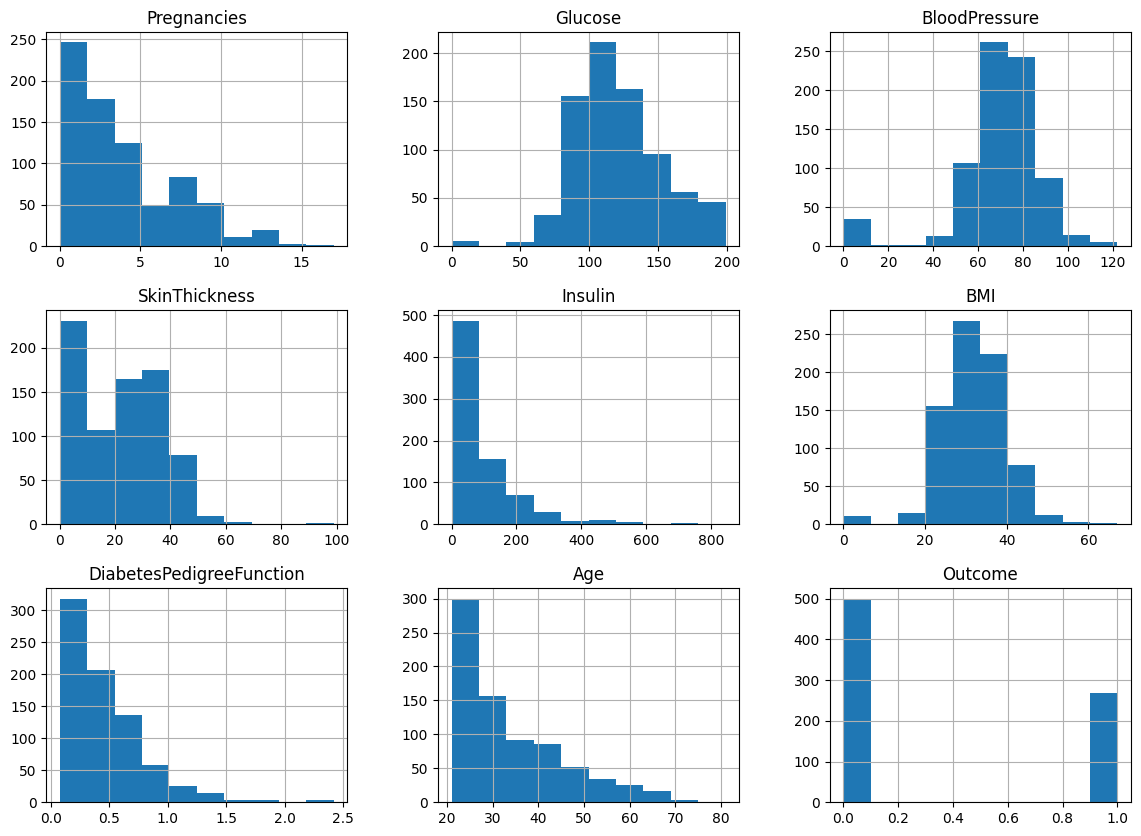

In [3]:
df.hist(figsize=(14,10))

In [4]:
statistic = df.describe().round(2)
statistic.loc['range'] = statistic.loc['max'] - statistic.loc['min']
statistic.loc['variance'] = df.var().round(2)
statistic


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00
range,17.00,199.00,122.00,99.00,846.00,67.10,2.34,60.00,1.00
variance,11.35,1022.25,374.65,254.47,13281.18,62.16,0.11,138.30,0.23


### Correlation Matrix

In [5]:

## Corelleation Matrix
correlation_matrix = df.corr()
correlation_matrix


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


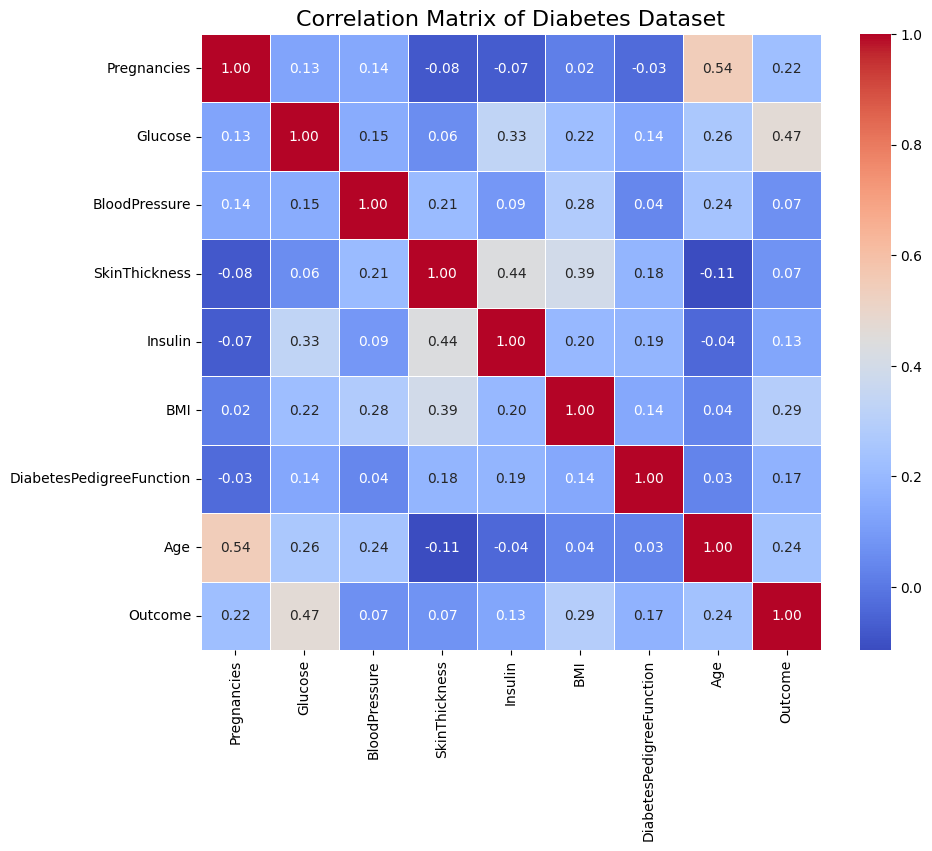

In [6]:
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f",linewidth=.5)
plt.title('Correlation Matrix of Diabetes Dataset', fontsize=16)
plt.savefig('correlation_matrix.png')
plt.show()

### Box Plot of each feature 

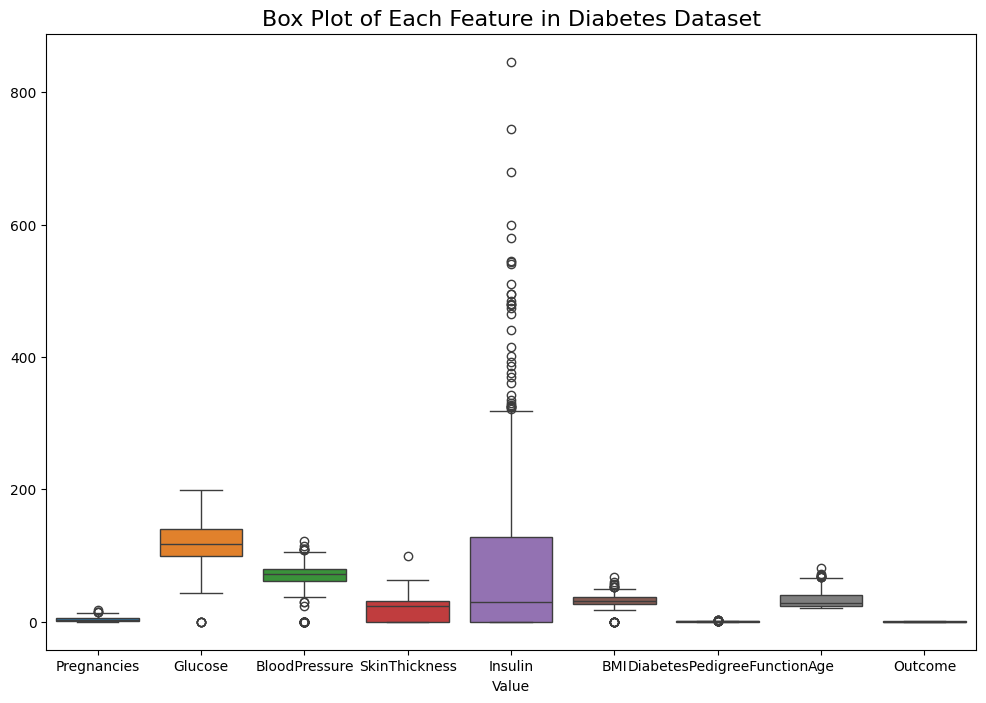

In [7]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df)
plt.title('Box Plot of Each Feature in Diabetes Dataset', fontsize=16)
plt.xlabel('Value')
plt.savefig('box_plot_features.png')
plt.show()

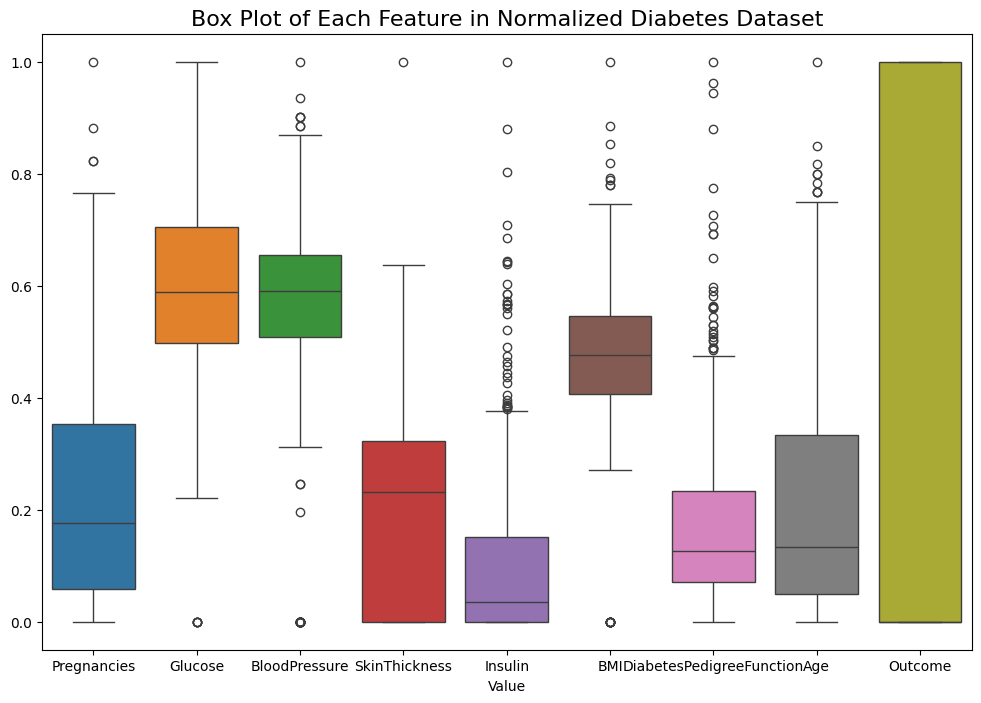

In [8]:
# normalize and check box plot again
scaler = MinMaxScaler()
normalized_data = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
plt.figure(figsize=(12, 8))
sns.boxplot(data=normalized_data)
plt.title('Box Plot of Each Feature in Normalized Diabetes Dataset', fontsize=16)
plt.xlabel('Value')
plt.savefig('box_plot_normalized_features.png')
plt.show()

### Scatter Plot of each feature vs Outcome

<Figure size 640x480 with 0 Axes>

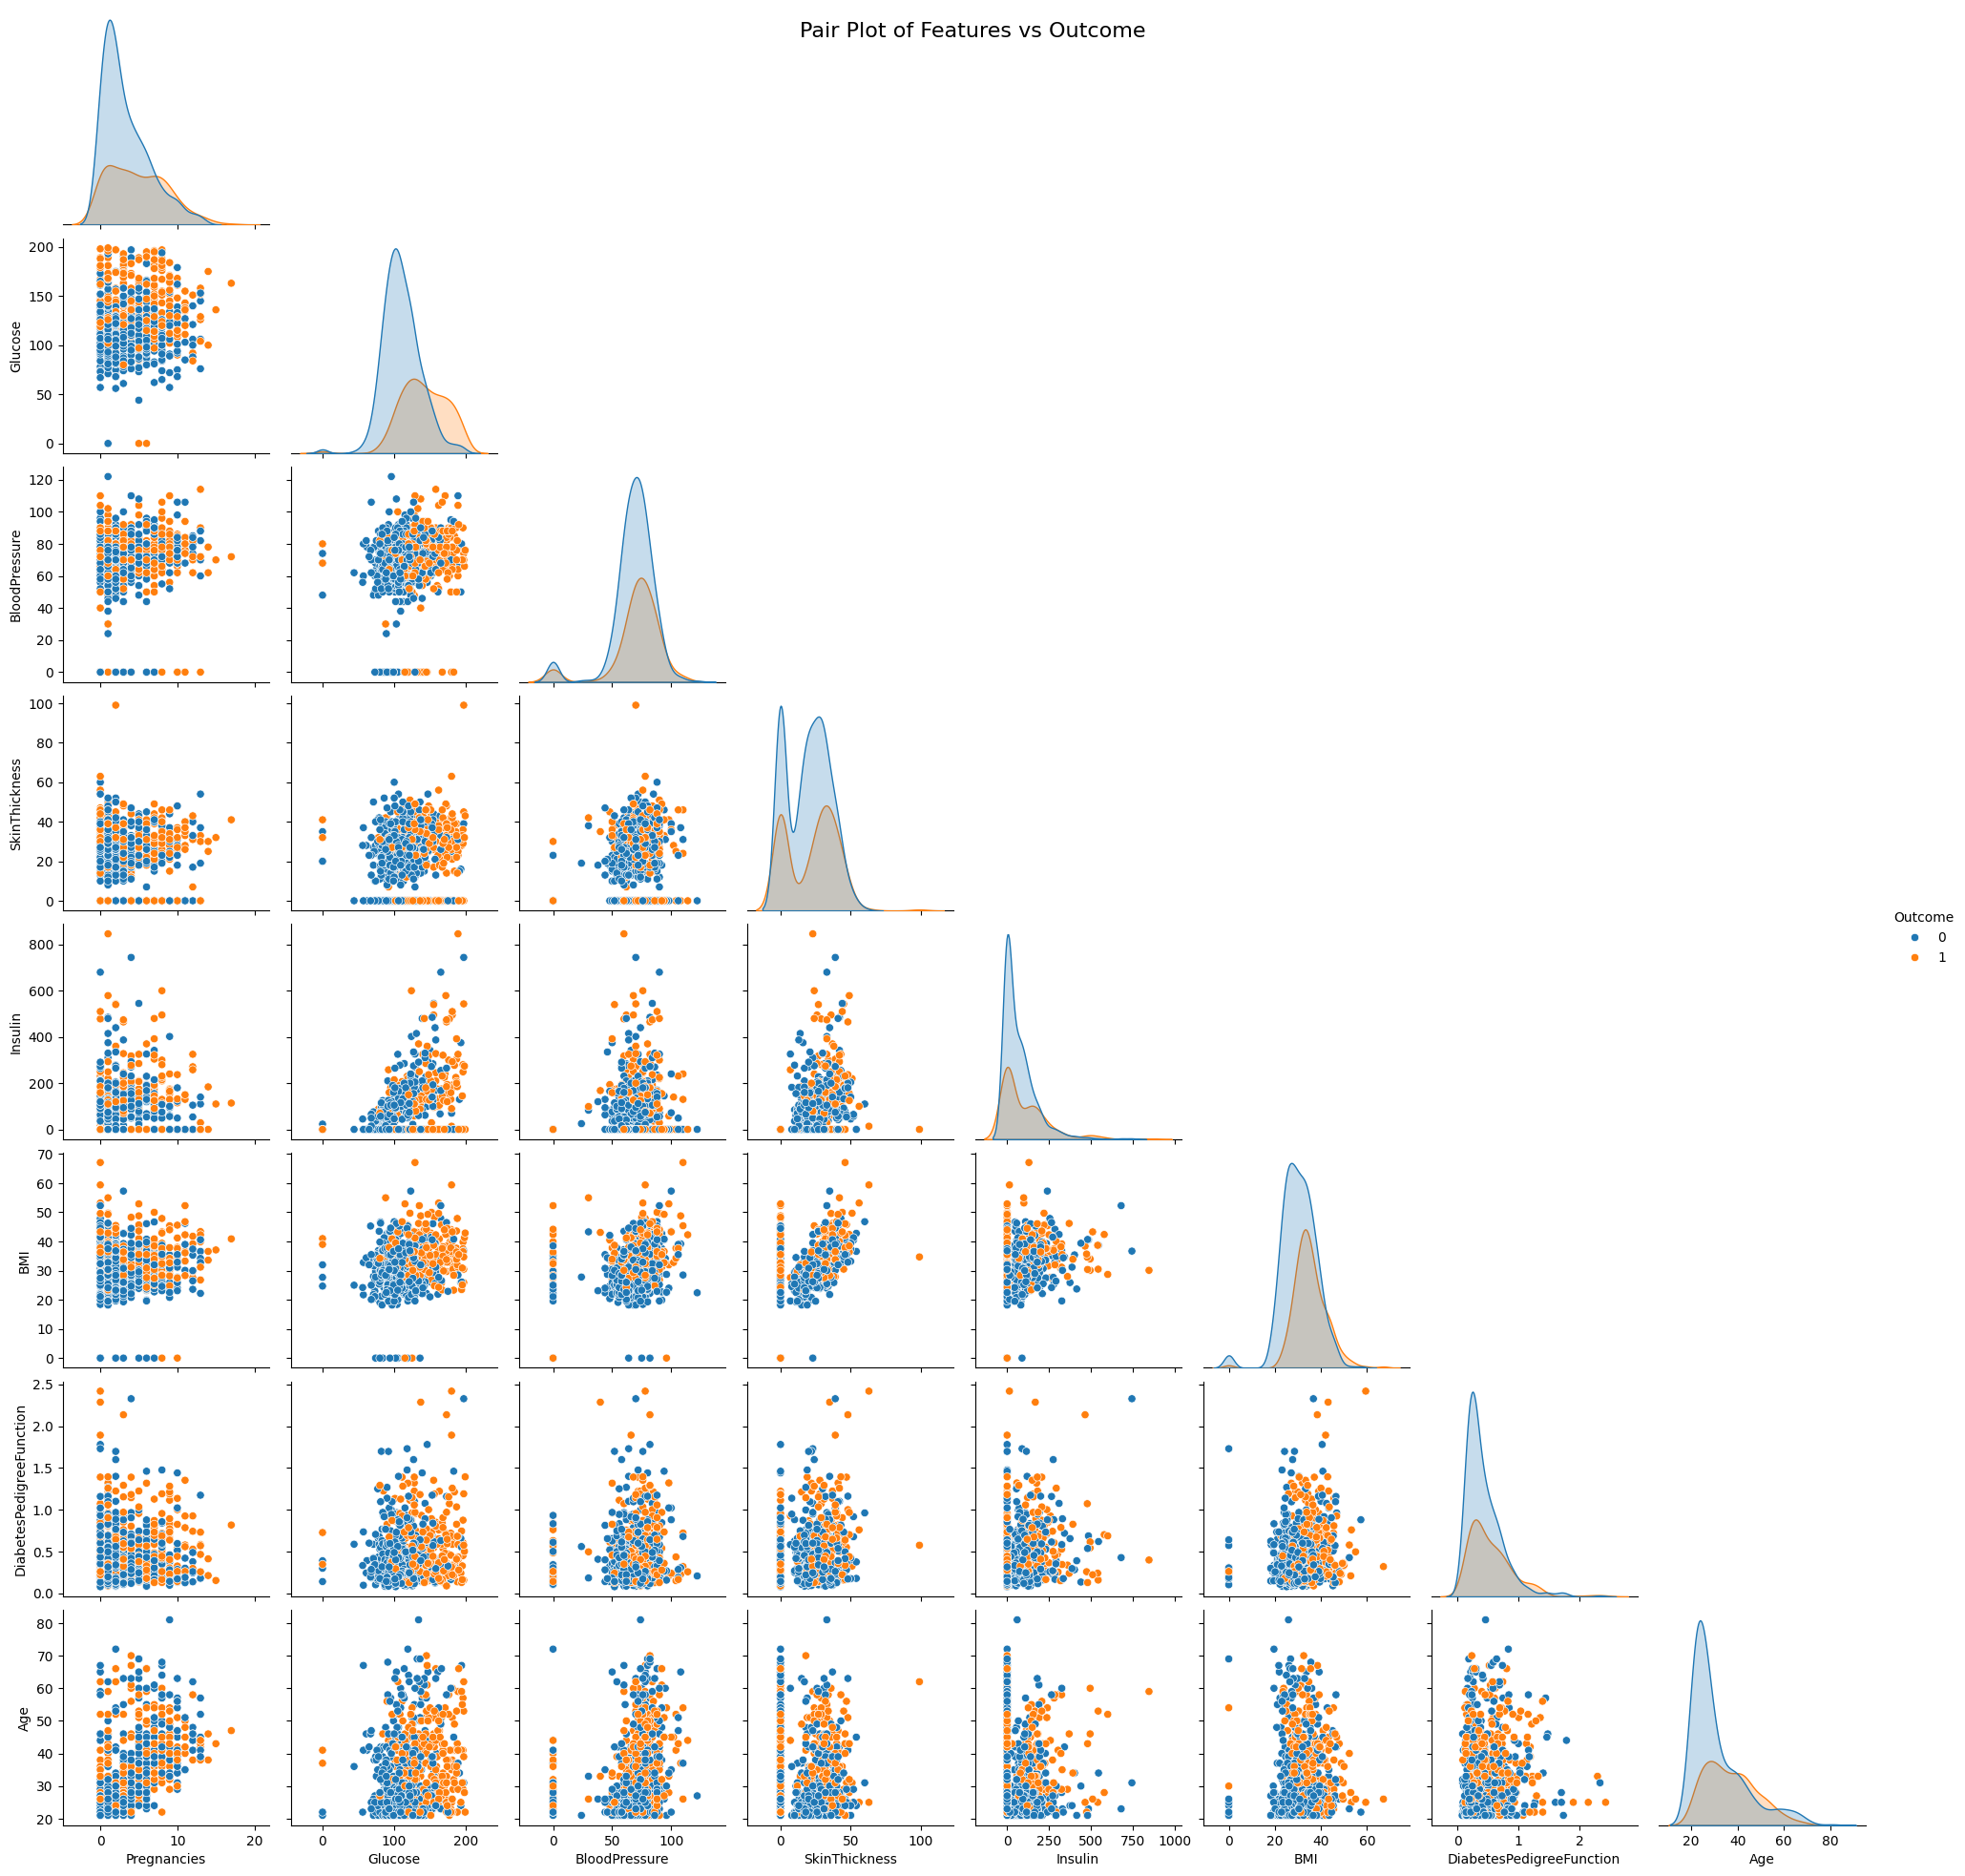

In [9]:
plt.figure()
sns.pairplot(
    df,
    vars=[df.columns[i] for i in range(len(df.columns)-1)],
    hue="Outcome",
    corner=True
)
plt.suptitle('Pair Plot of Features vs Outcome', fontsize=16)
plt.savefig('pair_plot_features_vs_outcome.png')
plt.show()


### Pie Chart of Outcome feature

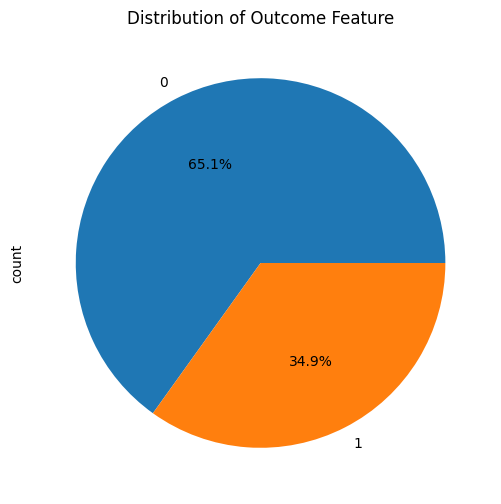

In [10]:
df["Outcome"].value_counts().plot.pie(autopct='%1.1f%%', figsize=(6, 6), title='Distribution of Outcome Feature')
plt.savefig('outcome_distribution_pie_chart.png')
plt.show()

### Check for missing Values

In [11]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### Check for zero values in features where it is not possible

In [12]:
zero_value_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'BMI','Age']
zero_value_counts = {col: (df[col] == 0).sum() for col in zero_value_columns}
zero_value_counts

{'Glucose': 5, 'BloodPressure': 35, 'SkinThickness': 227, 'BMI': 11, 'Age': 0}

## Preprocessing

In this section, we will preprocess the dataset to prepare it for building the Bayesian Network model. The preprocessing steps include handling missing values, and discretizing continuous variables into numeric bins.

for handling missing values we can use three methods:
1. Remove rows with missing values
2. Remove column with most missing values and remove rows with missing values in other columns
3. Impute missing values with mean/median/mode
4. Use advanced imputation techniques like KNN imputation or regression imputation

if we use firsy method we will lose a lot of data, so
we will use Impute missing values with mean and  KNN imputation for handling missing values. After that we will compare the results of each method.

for handling discretization we can use five methods:
1. Equal Width Binning
2. Quantile Binning
3. K-Means Binning
4. round Values to nearest integer

we will user K-Means and Quantile  Binning for discretization of continuous variables. After that we will compare the results of each method.

Challenges:
1. after handling missing values with mean imputaion or knn imputaion we will create new continuous columns, so we need to threat them diffrently in discretization step. We have two options here:
   - we can discretize them along with other continuous columns with same methods.
   - we can discretize them separately using round values to nearest integer method.
we will use the second option for discretization of imputed columns.

At the end of this section we will have four different preprocessed datasets to compare the results of each method.

### Handling Missing Values

#### Drop Column with most missing values and remove rows with missing values in other columns

In [13]:
df_dropped = df.copy()
df_dropped = df_dropped.drop('SkinThickness',axis=1)
zero_value_columns_dropped = ['Glucose', 'BloodPressure', 'BMI','Age']
for col in zero_value_columns_dropped:
    df_dropped = df_dropped[df_dropped[col] != 0]
display(df_dropped.isnull().sum())
df_dropped

Pregnancies                 0
Glucose                     0
BloodPressure               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

,Pregnancies,Glucose,BloodPressure,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,0,33.6,0.627,50,1
1,1,85,66,0,26.6,0.351,31,0
2,8,183,64,0,23.3,0.672,32,1
3,1,89,66,94,28.1,0.167,21,0
4,0,137,40,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...
763,10,101,76,180,32.9,0.171,63,0
764,2,122,70,0,36.8,0.340,27,0
765,5,121,72,112,26.2,0.245,30,0
766,1,126,60,0,30.1,0.349,47,1


#### Imputing missing values with mean

In [14]:
df_mean_imputed = df.copy()
for col in zero_value_columns:
    mean_value = df_mean_imputed[col].replace(0, np.nan).mean()
    df_mean_imputed[col] = df_mean_imputed[col].replace(0, mean_value)
display(df_mean_imputed[zero_value_columns].isnull().sum())
df_mean_imputed

Glucose          0
BloodPressure    0
SkinThickness    0
BMI              0
Age              0
dtype: int64

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.00000,0,33.6,0.627,50,1
1,1,85.0,66.0,29.00000,0,26.6,0.351,31,0
2,8,183.0,64.0,29.15342,0,23.3,0.672,32,1
3,1,89.0,66.0,23.00000,94,28.1,0.167,21,0
4,0,137.0,40.0,35.00000,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.00000,180,32.9,0.171,63,0
764,2,122.0,70.0,27.00000,0,36.8,0.340,27,0
765,5,121.0,72.0,23.00000,112,26.2,0.245,30,0
766,1,126.0,60.0,29.15342,0,30.1,0.349,47,1


#### Imputing missing values with KNN imputation

In [15]:
df_knn_imputed = df.copy()
df_knn_imputed[zero_value_columns] = df_knn_imputed[zero_value_columns].replace(0, np.nan)
imputer = KNNImputer(n_neighbors=10)
df_knn_imputed[zero_value_columns] = imputer.fit_transform(df_knn_imputed[zero_value_columns])
df_knn_imputed[zero_value_columns].isnull().sum()
df_knn_imputed

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,0,33.6,0.627,50.0,1
1,1,85.0,66.0,29.0,0,26.6,0.351,31.0,0
2,8,183.0,64.0,26.8,0,23.3,0.672,32.0,1
3,1,89.0,66.0,23.0,94,28.1,0.167,21.0,0
4,0,137.0,40.0,35.0,168,43.1,2.288,33.0,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180,32.9,0.171,63.0,0
764,2,122.0,70.0,27.0,0,36.8,0.340,27.0,0
765,5,121.0,72.0,23.0,112,26.2,0.245,30.0,0
766,1,126.0,60.0,33.6,0,30.1,0.349,47.0,1


### Show correlation matrix after handling missing values

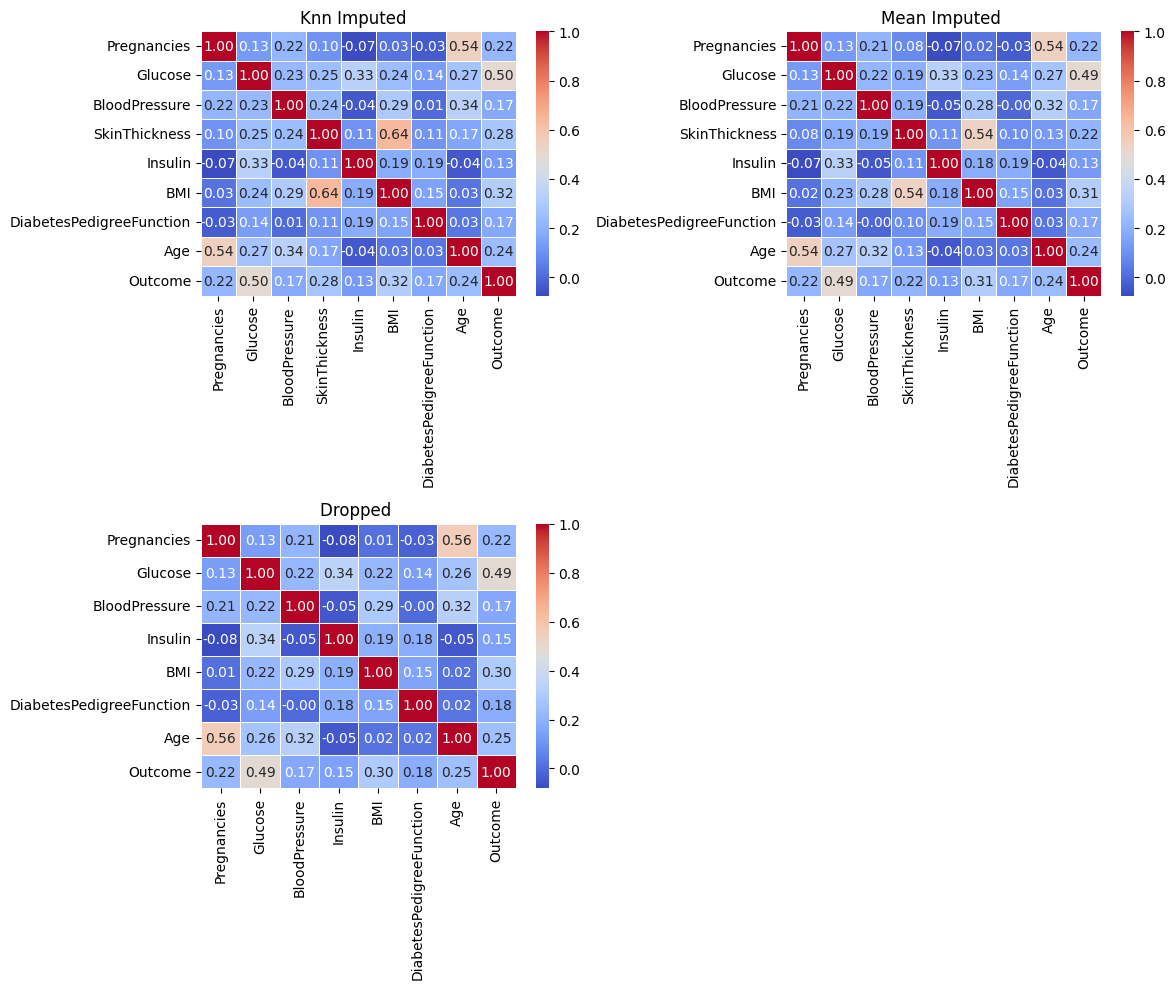

In [16]:
correlation_knn = df_knn_imputed.corr()
correlation_mean = df_mean_imputed.corr()
correlation_dropped = df_dropped.corr()
# plot all four correlation matrices
plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
sns.heatmap(correlation_knn, annot=True, cmap='coolwarm', fmt=".2f", linewidth=.5)
plt.title('Knn Imputed  ', fontsize=12)
plt.subplot(2, 2, 2)
sns.heatmap(correlation_mean , annot=True, cmap='coolwarm', fmt
=".2f", linewidth=.5)
plt.title('Mean Imputed ', fontsize=12)
plt.subplot(2, 2, 3)
sns.heatmap(correlation_dropped, annot=True, cmap='coolwarm',
    fmt=".2f", linewidth=.5)    
plt.title('Dropped ', fontsize=12)
plt.tight_layout()
plt.savefig('correlation_matrices_imputation.png')
plt.show()

### Palot of features after handling missing values

In [ ]:
plt.figure()
sns.pairplot(
    df_knn_imputed,
    vars=[  df_knn_imputed.columns[i] for i in range(len(df_knn_imputed.columns)-1)],
    hue="Outcome",
    corner=True
)
plt.suptitle('Pair Plot of Features vs Outcome', fontsize=16)
plt.savefig('pair_plot_after_handling_missing_values_knn.png')
plt.figure()
sns.pairplot(
    df_mean_imputed,
    vars=[  df_mean_imputed.columns[i] for i in range(len(df_mean_imputed.columns)-1)],
    hue="Outcome",
    corner=True
)
plt.suptitle('Pair Plot of Features vs Outcome', fontsize=16)
plt.savefig('pair_plot_after_handling_missing_values_mean.png')
plt.figure()
sns.pairplot(
    df_dropped,
    vars=[  df_dropped.columns[i] for i in range(len(df_dropped.columns)-1)],
    hue="Outcome",
    corner=True
)
plt.suptitle('Pair Plot of Features vs Outcome', fontsize=16)
plt.savefig('pair_plot_after_handling_missing_values_dropped.png')
plt.show()


### Result
After handling missing values using different methods, we obtained the following correlation matrices for each approach.
We decided to go forward with drop column approach as it provided a good balance between data retention and correlation structure preservation.


### Descretization of Continuous Variables

first we need to check ranges again.

In [19]:
statistic = df_dropped.describe().round(2)
statistic

,Pregnancies,Glucose,BloodPressure,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,724.00,724.00,724.00,724.00,724.00,724.00,724.00,724.00
mean,3.87,121.88,72.40,84.49,32.47,0.47,33.35,0.34
std,3.36,30.75,12.38,117.02,6.89,0.33,11.77,0.48
min,0.00,44.00,24.00,0.00,18.20,0.08,21.00,0.00
25%,1.00,99.75,64.00,0.00,27.50,0.24,24.00,0.00
50%,3.00,117.00,72.00,48.00,32.40,0.38,29.00,0.00
75%,6.00,142.00,80.00,130.50,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,846.00,67.10,2.42,81.00,1.00


#### Descretize with quantile Binning

In [20]:
def fd_q(x):
    iqr = np.subtract(*np.percentile(x, [75, 25]))
    if iqr == 0:
        return 2
    bw = 2 * iqr / (len(x) ** (1/3))
    return int(np.ceil((x.max() - x.min()) / bw))

**Note: Due Insuffiecient resources, we need to convert all features to categorical with qcut before fitting the model.**


In [21]:
df_quantile = df_dropped.copy()
optimal_q = {}

for col in df_dropped.columns:
    if col != 'Outcome':
        q = fd_q(df_dropped[col])
        optimal_q[col] = min(max(q, 2), 10)  # keep it reasonable
        
for col in df_quantile.columns:
    if col != 'Outcome':
        if df_quantile[col].nunique() > 10:
            df_quantile[col] = pd.qcut(df_quantile[col], q=optimal_q[col], labels=False, duplicates='drop')     
print("-------- Dropped DataFrame with Quantile Discretization --------")
display(df_quantile)
display(optimal_q)


-------- Dropped DataFrame with Quantile Discretization --------


,Pregnancies,Glucose,BloodPressure,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,5,8,4,0,5,7,8,1
1,0,0,2,0,2,4,5,0
2,6,9,2,0,0,7,5,1
3,0,1,2,2,2,1,0,0
4,0,7,0,4,9,9,5,1
...,...,...,...,...,...,...,...,...
763,7,2,6,4,5,1,9,0
764,1,5,3,0,7,4,3,0
765,4,5,4,2,1,2,5,0
766,0,6,1,0,3,4,8,1


{'Pregnancies': 10,
 'Glucose': 10,
 'BloodPressure': 10,
 'Insulin': 10,
 'BMI': 10,
 'DiabetesPedigreeFunction': 10,
 'Age': 10}

##### Descretize with K-Means Binning

In [22]:
df_kmeans = df_dropped.copy()
kmeans = KMeans(n_clusters=10, random_state=42)

for col in df_kmeans.columns:
    if col != 'Outcome':
        if df_kmeans[col].nunique() > 10:
            new_column_mean = kmeans.fit_predict(df_kmeans[[col]])
            df_kmeans[col] = new_column_mean

print("-------- Dropped DataFrame with KMeans Discretization --------")
display(df_kmeans)


-------- Dropped DataFrame with KMeans Discretization --------


,Pregnancies,Glucose,BloodPressure,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,4,3,2,8,9,4,1,1
1,0,4,6,8,2,8,9,0
2,1,1,6,8,6,4,9,1
3,0,2,6,7,1,6,2,0
4,5,7,4,6,8,7,9,1
...,...,...,...,...,...,...,...,...
763,3,6,5,6,9,6,5,0
764,7,0,2,8,3,8,0,0
765,9,0,2,3,2,1,0,0
766,0,9,1,8,1,8,1,1


## Analysing Dataset Characteristics After Cleaning

### Correlation Matrix


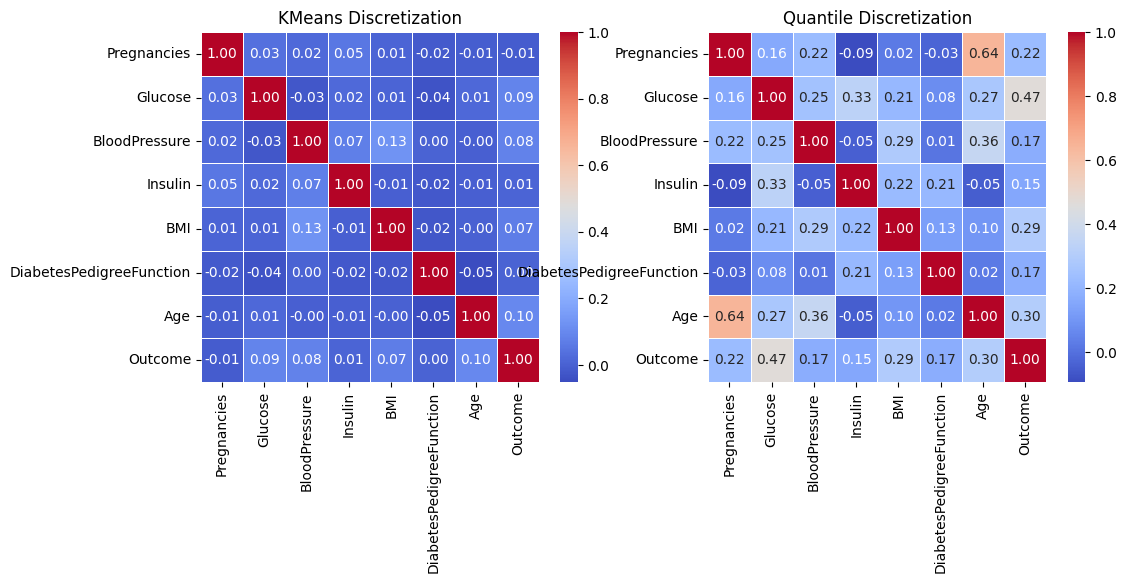

In [23]:
correlation_kmeans = df_kmeans.corr()
correlation_quantile = df_quantile.corr()

# plot all four correlation matrices
plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
sns.heatmap(correlation_kmeans, annot=True, cmap='coolwarm', fmt=".2f", linewidth=.5)
plt.title('KMeans Discretization', fontsize=12)
plt.subplot(2, 2, 2)
sns.heatmap(correlation_quantile, annot=True, cmap='coolwarm', fmt
=".2f", linewidth=.5)
plt.title('Quantile Discretization', fontsize=12)

plt.savefig('correlation_matrices_comparison_after_discretization.png')
plt.show()

### Pair plot of each changed feature vs Outcome


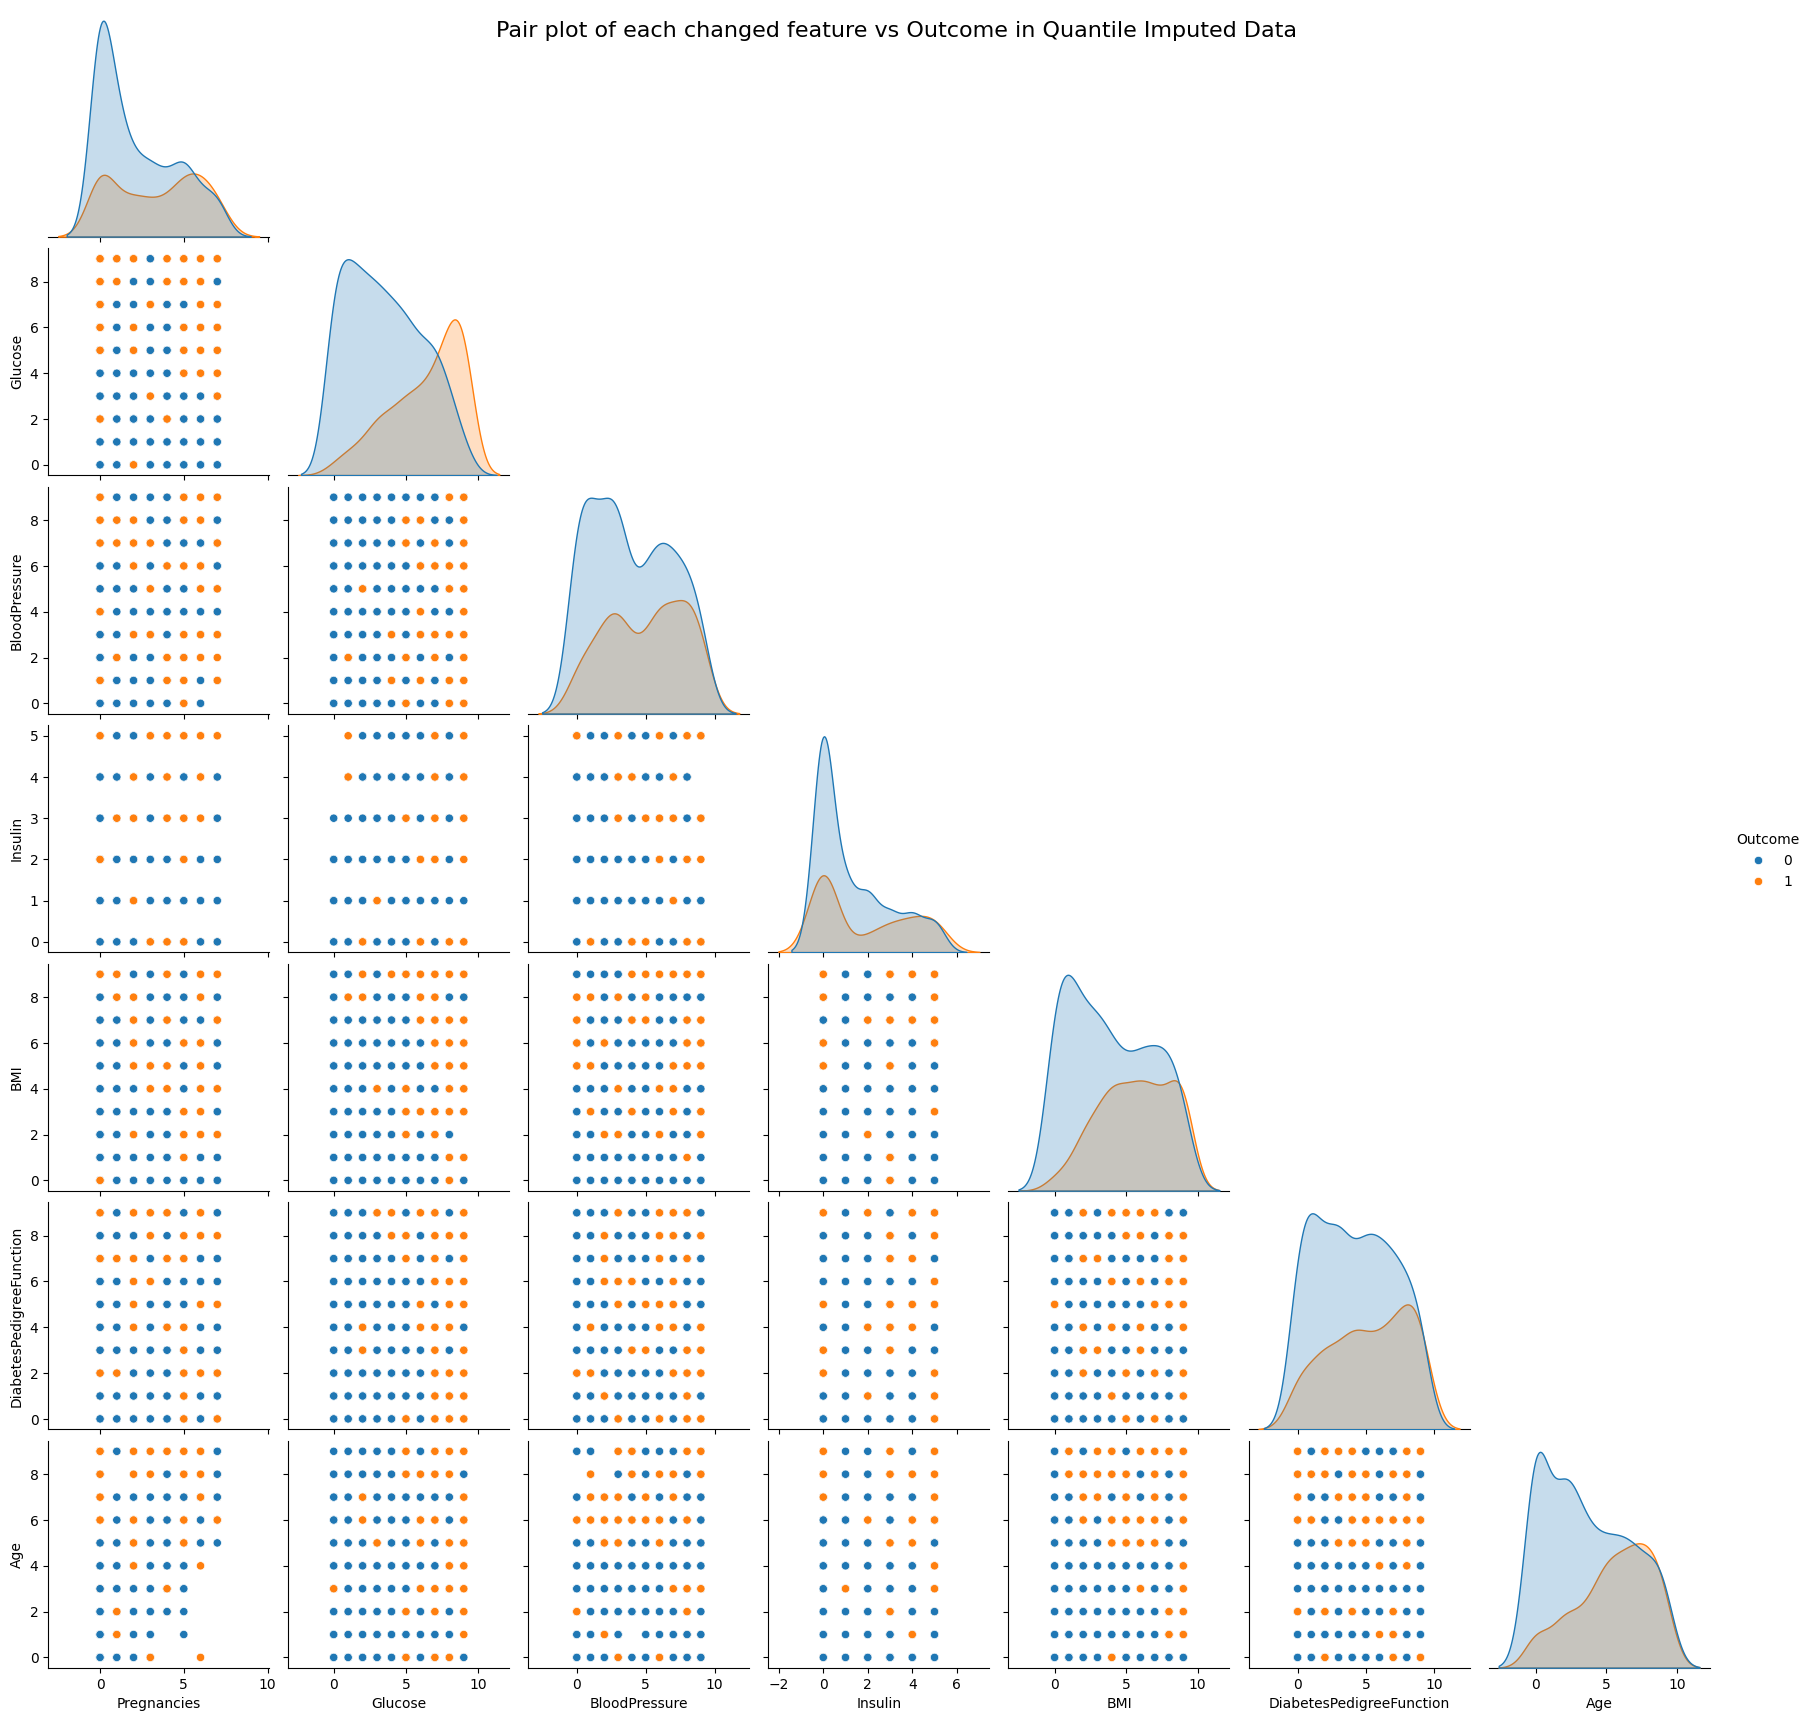

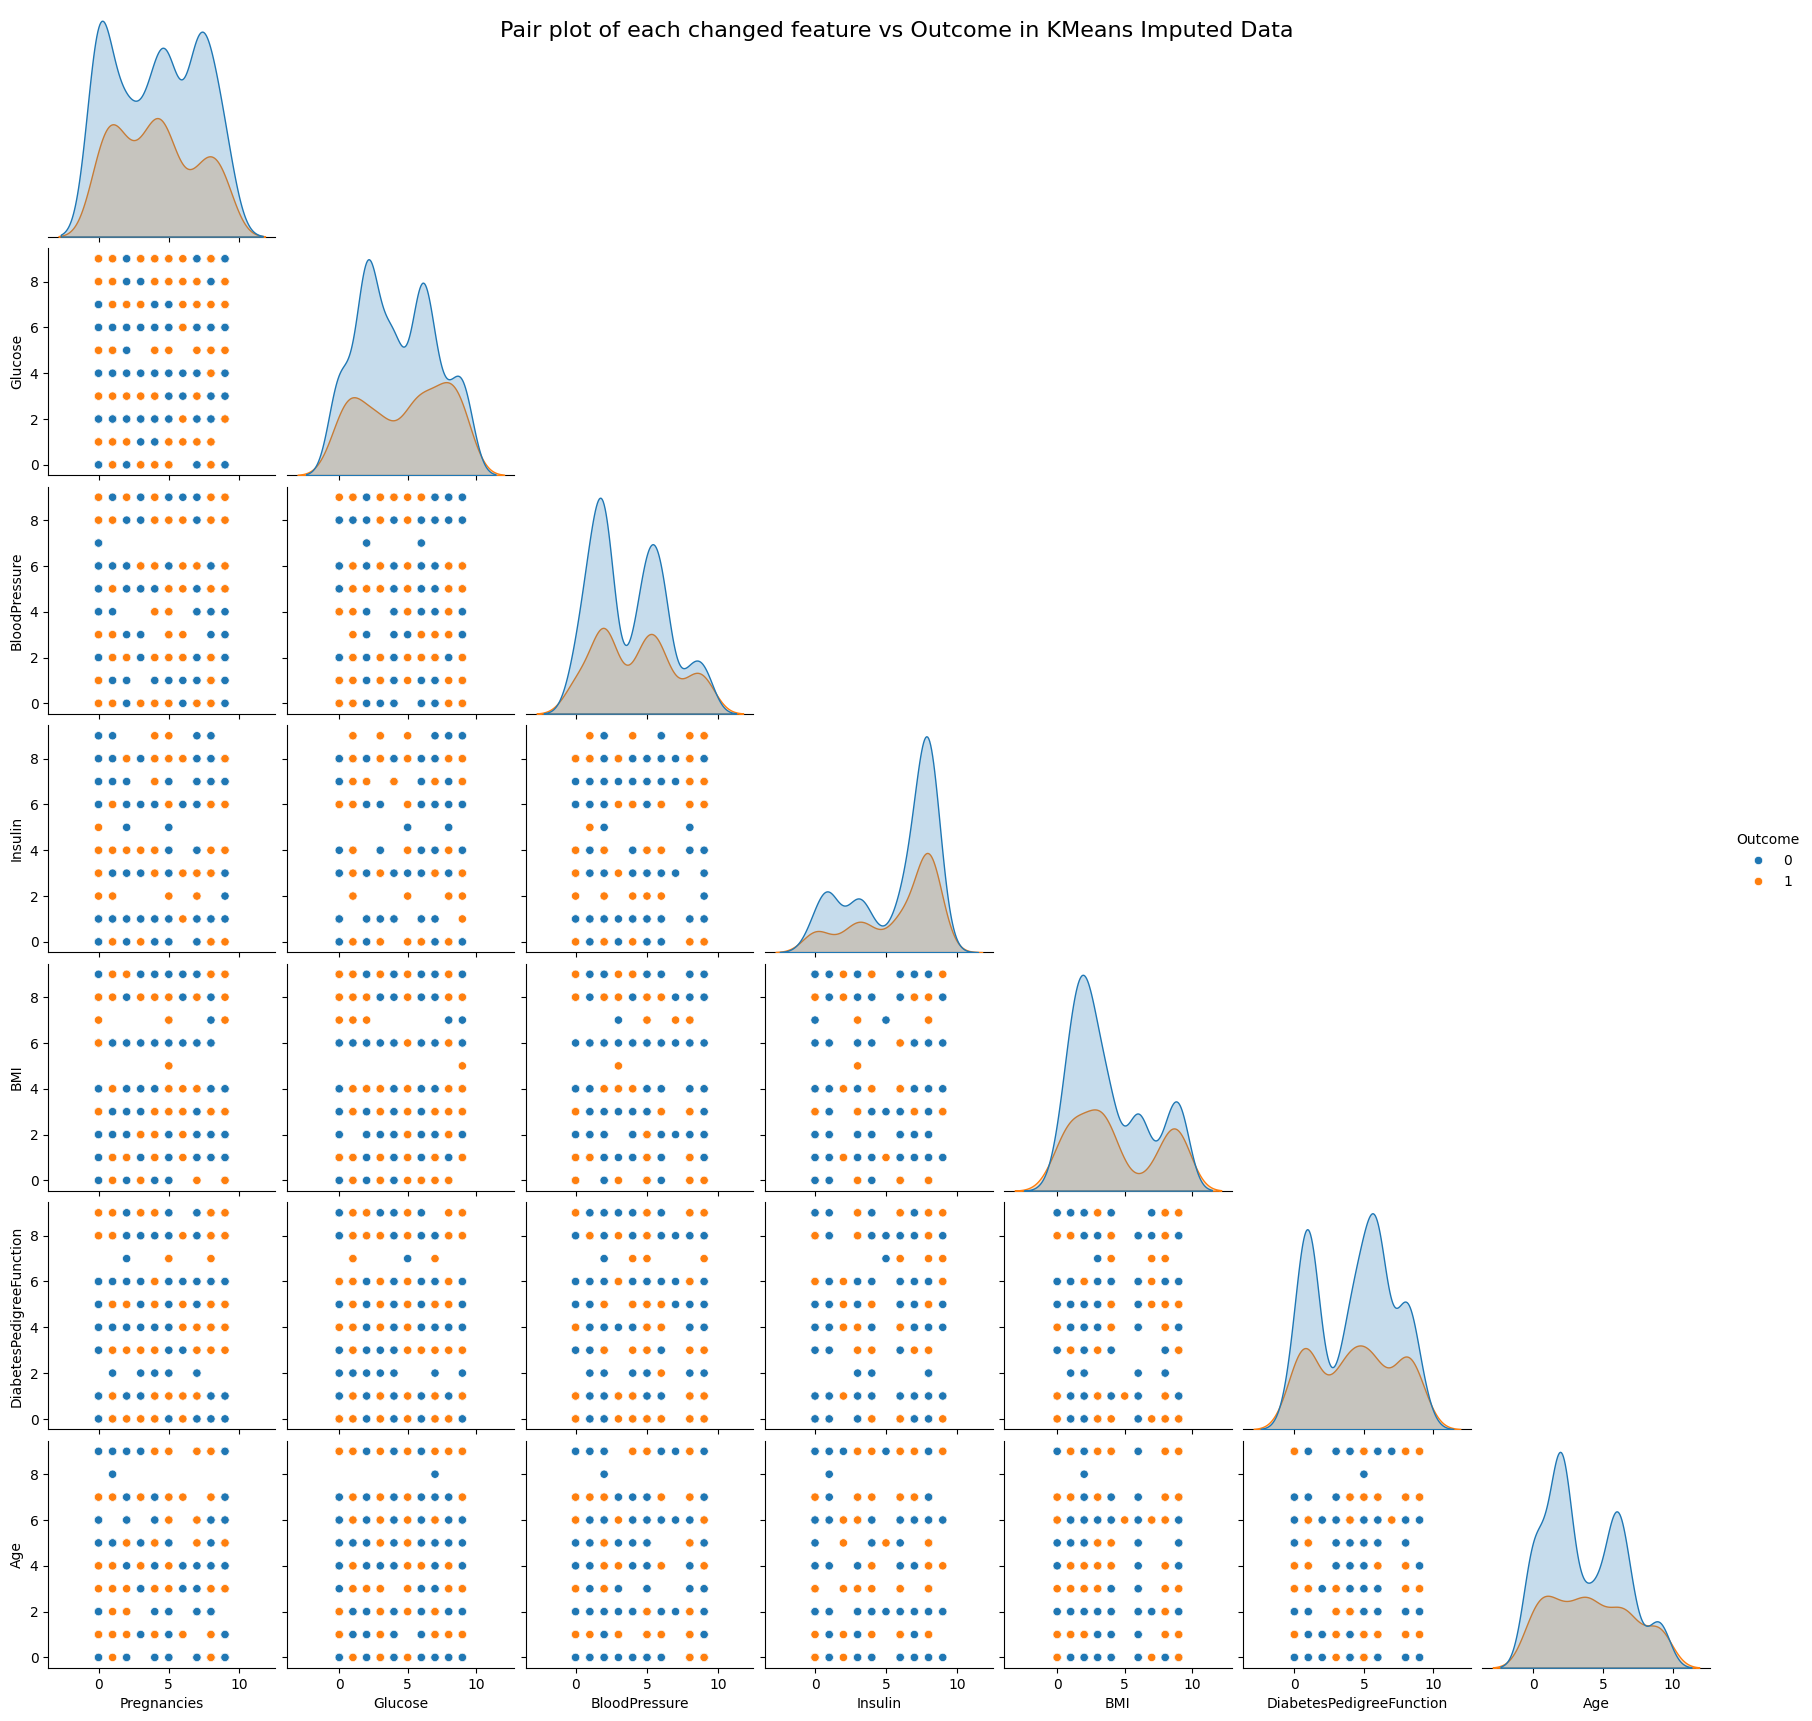

In [24]:
ploted_columns = df_kmeans.columns.tolist()
ploted_columns.remove("Outcome")
sns.pairplot(
    df_quantile,
    vars=ploted_columns,
    hue="Outcome",
    corner=True
)
plt.suptitle('Pair plot of each changed feature vs Outcome in Quantile Imputed Data', fontsize=16)
plt.savefig('pair_plot_changed_features_vs_outcome_quantile.png')
plt.show()
# knn kmeans
sns.pairplot(
    df_kmeans,
    vars=ploted_columns,
    hue="Outcome",
    corner=True
)
plt.suptitle('Pair plot of each changed feature vs Outcome in KMeans Imputed Data', fontsize=16)
plt.savefig('pair_plot_changed_features_vs_outcome_kmeans.png')
plt.show()



### Results
we can see kmeans discretization had bad effect on pair and correlation plots compared to quantile discretization. So we will go forward with quantile discretized dataset for building the Bayesian Network model.

## Training Bayesian Network

for Training Bayesian Network we will use pgmpy library. We will follow these steps:
1. Define the structure of the Bayesian Network which there is three options here:
   - we could define the structure manually based on domain knowledge.
   - we could use defualt naive bayes structure and connect all features to outcome.
   - we could use structure learning algorithms to learn the structure from data.
   - we could use a hybrid approach where we define some parts of the structure manually and learn other parts from data.
we will go through all three options and compare the results.

2. Find the Conditional Probability Distributions (CPDs) for each node in the network.
3. Perform inference on the Bayesian Network to make analyses with variable elimination. We will perform infrences to analyses the result of different scenarios.

### Define the structure of the Bayesian Network

#### Manually define the structure based on domain knowledge

in here we use the custom structure based on domain knowledge about diabetes. Basic Naive bayes structure.

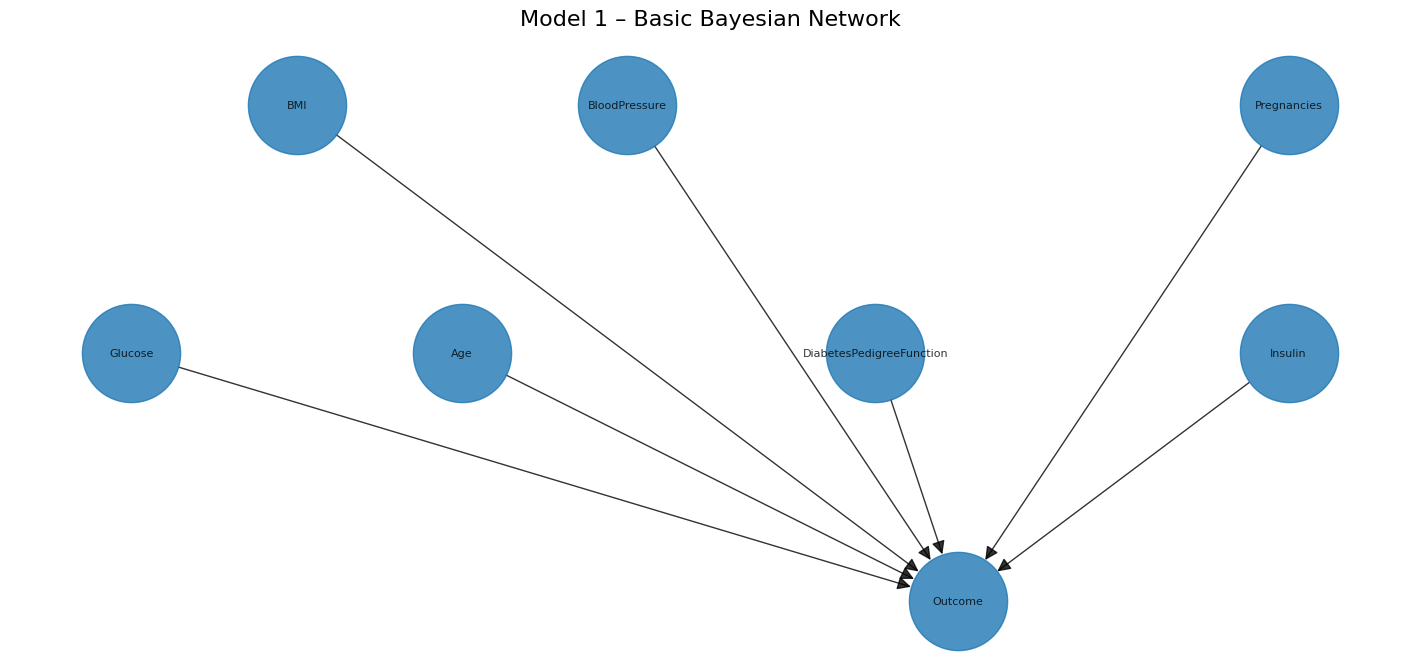

In [25]:
naive_bayes = DiscreteBayesianNetwork([
    ("Glucose", "Outcome"),
    ("BMI", "Outcome"),
    ("Age", "Outcome"),
    ("BloodPressure", "Outcome"),
    ("DiabetesPedigreeFunction", "Outcome") ,
    ("Insulin", "Outcome"),
    ("Pregnancies", "Outcome"),

])

pos_basic = {
    "Glucose": (0, 2), "BMI": (2, 4), "Age": (4, 2),
    "BloodPressure": (6, 4), "DiabetesPedigreeFunction": (9, 2),
    "Insulin": (14, 2), "Pregnancies": (14, 4),
    "Outcome": (10, 0)
}

plt.figure(figsize=(14, 6))
nx.draw(naive_bayes, pos_basic, with_labels=True, node_size=5000,
        font_size=8, arrowsize=20, alpha=0.8)

plt.title("Model 1 – Basic Bayesian Network", fontsize=16, pad=20)
plt.savefig('basic_bayesian_network.png')
plt.show()

Here is the second model where we connect the features based on their relations and influences on each other.

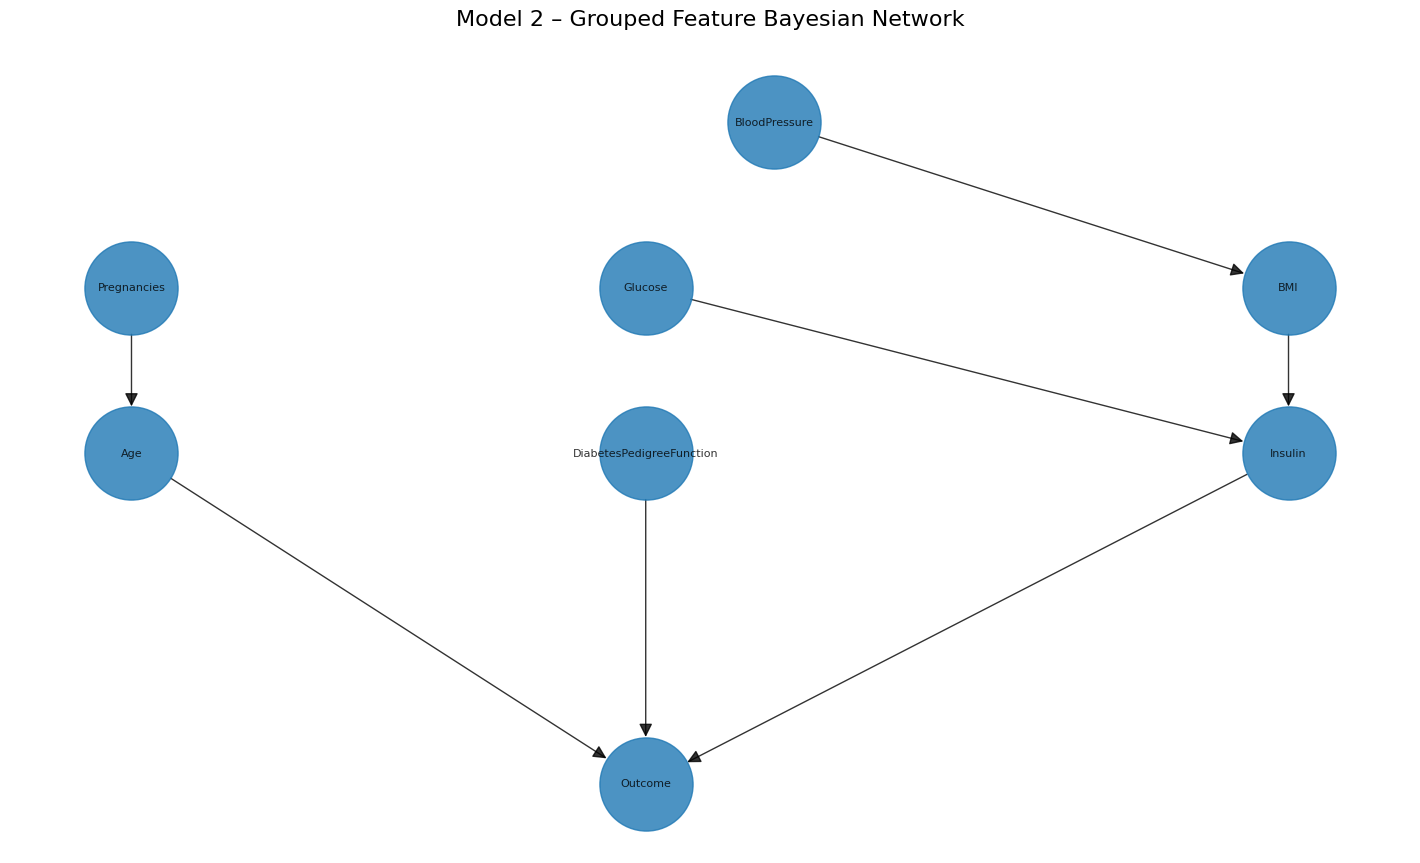

In [26]:
grouped_model = DiscreteBayesianNetwork([
   
    ("Glucose", "Insulin"),
    ("BMI", "Insulin"),
    ("Pregnancies", "Age"),
    ("BloodPressure", "BMI"),
    ("DiabetesPedigreeFunction", "Outcome") ,
    ("Insulin", "Outcome"),
    ("Age", "Outcome"),

    
])

pos_grouped = {
   "Glucose": (5, 3), "BMI": (10, 3), 
    "Age": (1, 2),
    "Pregnancies": (1, 3),
    "BloodPressure": (6, 4), "DiabetesPedigreeFunction": (5, 2), "Insulin": (10, 2),
    "Outcome": (5, 0),
   
}

plt.figure(figsize=(14, 8))
nx.draw(grouped_model, pos_grouped, with_labels=True, node_size=4500,
        font_size=8, arrowsize=20, alpha=0.8)

plt.title("Model 2 – Grouped Feature Bayesian Network", fontsize=16, pad=20)
plt.savefig('grouped_feature_bayesian_network.png')
plt.show()


Here we use the structure learning algorithm to learn the structure from data.
First we will use Tree Search algorithm to learn the structure from data.
Then we will use Hill Climb Search algorithm to learn the structure from data.

We need to define the models for our data.

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'Insulin': 'N', 'BMI': 'N', 'DiabetesPedigreeFunction': 'N', 'Age': 'N', 'Outcome': 'N'}
Building tree: 100%|██████████████████████████| 28/28.0 [00:00<00:00, 30.03it/s]


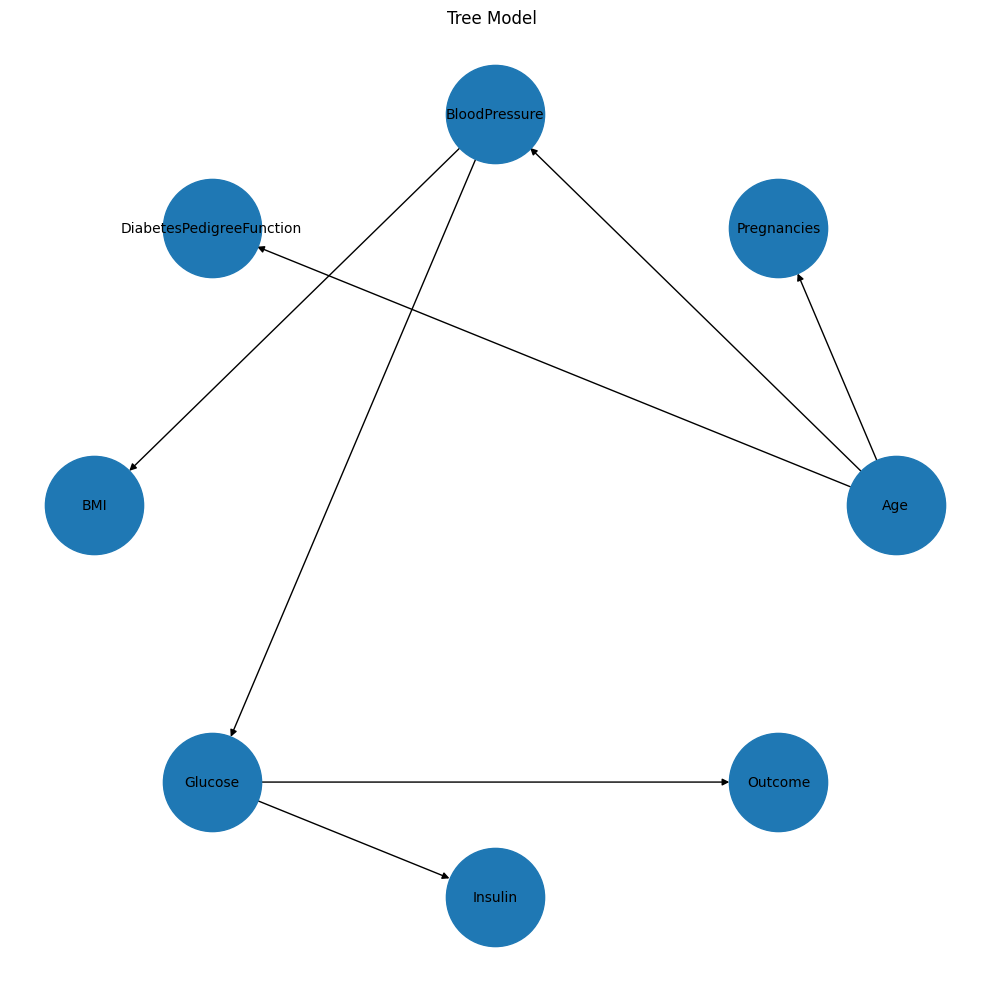

In [27]:
ts = TreeSearch(data=df_quantile, )
tree_model = ts.estimate(show_progress=True)
tree_models = [
    (tree_model, 'Tree Model '),
]
fig, axes = plt.subplots(1, 1, figsize=(10, 10))
axes = [axes]

for ax, (tree_model, title) in zip(axes, tree_models):
    pos = nx.drawing.layout.circular_layout(tree_model)

    nx.draw_networkx(
        tree_model,
        pos=pos,
        ax=ax,
        node_size=5000,
        font_size=10
    )

    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.savefig("all_tree_models.png")
plt.show()
# define bayesian models based on learned structures
tree_models = {
    'tree': DiscreteBayesianNetwork(tree_model.edges()),
  
}


Here we do a hill climb search with diffrent scoring methods.
- k2
- AIC 

we have diffrent scoring methods and at all we have 5 diffrent models to compare plus 4 models from tree search and 2 custom models.

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'Insulin': 'N', 'BMI': 'N', 'DiabetesPedigreeFunction': 'N', 'Age': 'N', 'Outcome': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'Insulin': 'N', 'BMI': 'N', 'DiabetesPedigreeFunction': 'N', 'Age': 'N', 'Outcome': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'Insulin': 'N', 'BMI': 'N', 'DiabetesPedigreeFunction': 'N', 'Age': 'N', 'Outcome': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'Insulin': 'N', 'BMI': 'N', 'DiabetesPedigreeFunction': 'N', 'Age': 'N', 'Out

Expert Knowledge:
Forbidden Edges: {('Outcome', 'Insulin'), ('Outcome', 'Glucose'), ('Outcome', 'DiabetesPedigreeFunction'), ('Outcome', 'BloodPressure'), ('Outcome', 'Age'), ('Outcome', 'BMI'), ('Glucose', 'Insulin'), ('Glucose', 'BMI'), ('Glucose', 'BloodPressure'), ('Outcome', 'Pregnancies'), ('Insulin', 'BloodPressure')}
Required Edges: {('Insulin', 'Glucose'), ('Glucose', 'Outcome'), ('BMI', 'Glucose')}


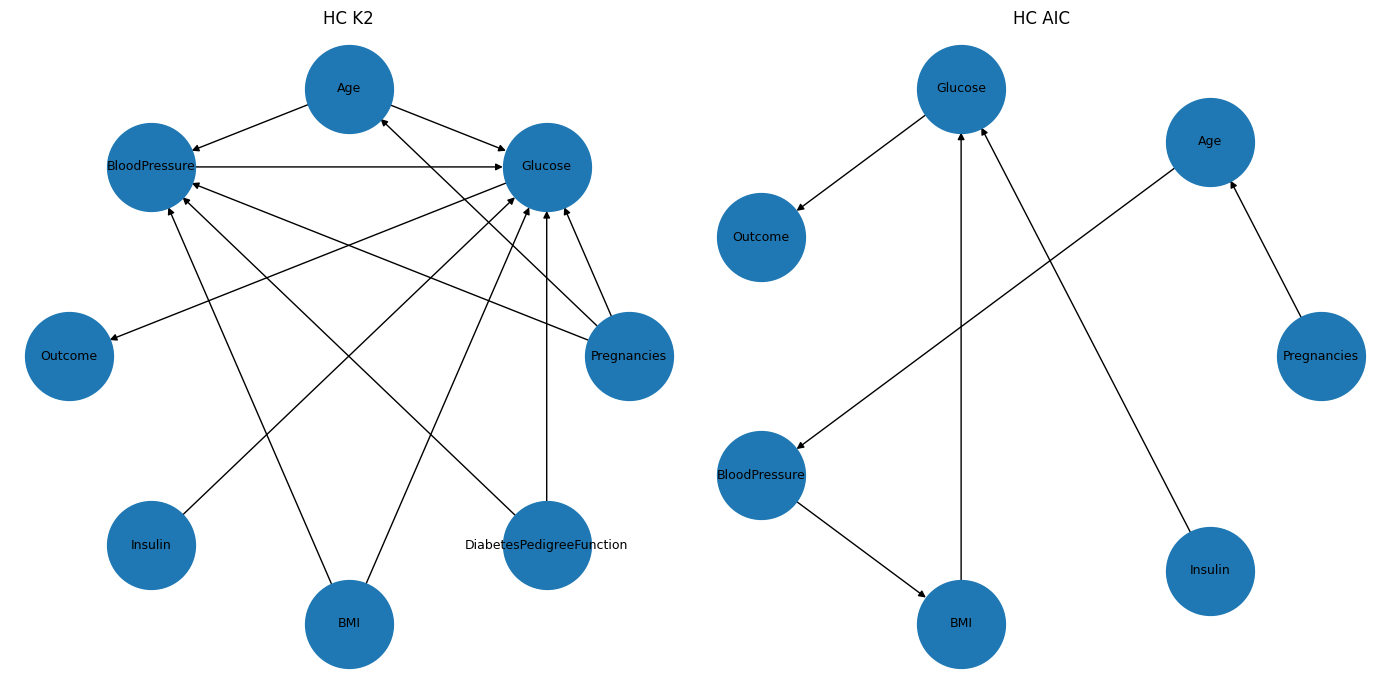

In [28]:
scorers = ['k2', 'aic']

hc_models = {}
forbidden_edges = [('Outcome', col) for col in df_quantile.columns if col != 'Outcome']
forbidden_edges.append(('Glucose', 'Insulin'))
forbidden_edges.append(('Glucose', 'BMI'))
forbidden_edges.append(('Glucose', 'BloodPressure'))
forbidden_edges.append(('Insulin', 'BloodPressure'))

required_edges = []
required_edges.append(('Insulin', 'Glucose'))
required_edges.append(('Glucose', 'Outcome'))
required_edges.append(('BMI', 'Glucose'))

expert_knowledge = ExpertKnowledge(
    forbidden_edges=forbidden_edges,
    required_edges=required_edges
)
print("Expert Knowledge:")
print("Forbidden Edges:", expert_knowledge.forbidden_edges)
print("Required Edges:", expert_knowledge.required_edges)
for scorer_name in scorers:
    if scorer_name == 'k2':
        scorer = K2(df_quantile)
    elif scorer_name == 'aic':
        scorer = AIC(df_quantile)
    hc = HillClimbSearch(data=df_quantile)
    hc_model = hc.estimate(scoring_method=scorer, show_progress=False, expert_knowledge=expert_knowledge )
    model_key = f'hc_{scorer_name}'
    hc_models[model_key] = DiscreteBayesianNetwork(hc_model.edges())
        # plot the all models in one figure

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(7 * 2, 7 * 1)
)

axes = axes.flatten()

for ax, (model_key, hc_model) in zip(axes, hc_models.items()):
    pos = nx.drawing.layout.circular_layout(hc_model)

    nx.draw_networkx(
        hc_model,
        pos=pos,
        ax=ax,
        node_size=4000,
        font_size=9
    )

    title = model_key.replace('_', ' ').upper()
    ax.set_title(title)
    ax.axis("off")

# Hide unused subplots (if any)
for ax in axes[len(hc_models):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("all_hill_climb_models.png")
plt.show()




In [29]:
models = [
        ('naive_bayes', naive_bayes),
          ('grouped', grouped_model),
            ('tree', tree_models['tree']),
            ('hc_k2', hc_models['hc_k2']),
            ('hc_aic', hc_models['hc_aic'])]

for name, model in models:
    print(f'Computing CPD for {name} model')
    model.fit(df_quantile, estimator=MaximumLikelihoodEstimator)



INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'Insulin': 'N', 'BMI': 'N', 'DiabetesPedigreeFunction': 'N', 'Age': 'N', 'Outcome': 'N'}


Computing CPD for naive_bayes model


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'Insulin': 'N', 'BMI': 'N', 'DiabetesPedigreeFunction': 'N', 'Age': 'N', 'Outcome': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'Insulin': 'N', 'BMI': 'N', 'DiabetesPedigreeFunction': 'N', 'Age': 'N', 'Outcome': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'Insulin': 'N', 'BMI': 'N', 'DiabetesPedigreeFunction': 'N', 'Age': 'N', 'Outcome': 'N'}


Computing CPD for grouped model
Computing CPD for tree model
Computing CPD for hc_k2 model


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'Insulin': 'N', 'BMI': 'N', 'DiabetesPedigreeFunction': 'N', 'Age': 'N', 'Outcome': 'N'}


Computing CPD for hc_aic model


In [30]:
cpd_models = [
            ('tree', tree_models['tree']),
            ('hc_k2', hc_models['hc_k2']),
            ('hc_aic', hc_models['hc_aic'])]

for name, model in cpd_models:
    print(f'CPDs for {name} model:')
    for cpd in model.get_cpds():
        print(cpd)
        print() 

CPDs for tree model:
+--------+-----------+
| Age(0) | 0.174033  |
+--------+-----------+
| Age(1) | 0.0483425 |
+--------+-----------+
| Age(2) | 0.121547  |
+--------+-----------+
| Age(3) | 0.0856354 |
+--------+-----------+
| Age(4) | 0.0828729 |
+--------+-----------+
| Age(5) | 0.0994475 |
+--------+-----------+
| Age(6) | 0.0980663 |
+--------+-----------+
| Age(7) | 0.10221   |
+--------+-----------+
| Age(8) | 0.0911602 |
+--------+-----------+
| Age(9) | 0.0966851 |
+--------+-----------+

+----------------+-----+---------------------+
| Age            | ... | Age(9)              |
+----------------+-----+---------------------+
| Pregnancies(0) | ... | 0.12857142857142856 |
+----------------+-----+---------------------+
| Pregnancies(1) | ... | 0.08571428571428572 |
+----------------+-----+---------------------+
| Pregnancies(2) | ... | 0.04285714285714286 |
+----------------+-----+---------------------+
| Pregnancies(3) | ... | 0.08571428571428572 |
+----------------+-----+-

In [31]:

for name, model in models:
    model_nodes = list(model.nodes())
    print(f'Result of  model: {name}')
    print(f'Independence assertions num: {len(model.get_independencies().get_assertions())}')
    print(f'Local semantics of the current model:\n{model.local_independencies(model_nodes)}')
    print('Checking Markov blankets')
    for node in model_nodes:
        print(f'The Markov blanket of node {node} is {model.get_markov_blanket(node)}')
    print()

Result of  model: naive_bayes
Independence assertions num: 21
Local semantics of the current model:
(Glucose ⟂ DiabetesPedigreeFunction, Age, Insulin, BMI, Pregnancies, BloodPressure)
(BMI ⟂ DiabetesPedigreeFunction, Age, Insulin, Glucose, Pregnancies, BloodPressure)
(Age ⟂ DiabetesPedigreeFunction, Insulin, BMI, Glucose, Pregnancies, BloodPressure)
(BloodPressure ⟂ DiabetesPedigreeFunction, Age, Insulin, BMI, Glucose, Pregnancies)
(DiabetesPedigreeFunction ⟂ Age, Insulin, BMI, Glucose, Pregnancies, BloodPressure)
(Insulin ⟂ DiabetesPedigreeFunction, Age, BMI, Glucose, Pregnancies, BloodPressure)
(Pregnancies ⟂ DiabetesPedigreeFunction, Age, Insulin, BMI, Glucose, BloodPressure)
Checking Markov blankets
The Markov blanket of node Glucose is ['DiabetesPedigreeFunction', 'Age', 'BMI', 'Outcome', 'BloodPressure', 'Insulin', 'Pregnancies']
The Markov blanket of node Outcome is ['DiabetesPedigreeFunction', 'Age', 'BMI', 'Glucose', 'BloodPressure', 'Insulin', 'Pregnancies']
The Markov blanke

In [32]:
inferences = [(name, VariableElimination(model)) for name, model in models]

## Analyses 

In this section we are going to analys diffrent Questiions about the dataset

In [192]:
def plot_result(answer_scores: dict, file_name: str, title: str, x_values, x_label: str):
    fig, axes = plt.subplots(3, 2, figsize=(16, 9), sharey=True)
    axes = axes.flatten()

    for ax, name in zip(axes, answer_scores.keys()):
        if(len(answer_scores[name].items())==0):
            ax.axis('off')
            continue
        ax.set_title(f"{name} model")

        outcomes_1 = []

        for _, probs in answer_scores[name].items():
            outcomes_1.append(probs[1])  # P(Outcome = 1)

        ax.plot(x_values, outcomes_1, marker='o', label="P(Outcome=1)")
        ax.set_xlabel(x_label)
        ax.set_ylabel("Probability")
        ax.set_ylim(0, 1)
        ax.legend()
        ax.grid(True, alpha=0.3)
    axes[5].axis('off')  # Hide unused subplot
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    fig.savefig(file_name)
    plt.show()

In [193]:
def print_outcome_change(answer_scores, variable_name="Age", condition_note=None):
    header = f"Change in P(Outcome=1) as {variable_name} increases"
    if condition_note:
        header += f" ({condition_note})"

    print(f"\n{header}:\n")

    for model_name, results in answer_scores.items():
        probs = [v[1] for v in results.values()]  # Outcome = 1

        start = probs[0]
        end = probs[-1]
        abs_change = end - start

        if start > 0:
            pct_change = (abs_change / start) * 100
            pct_str = f"{pct_change:+.1f}%"
        else:
            pct_str = "undefined"

        print(
            f"{model_name:10s} | "
            f"start={start:.3f}, end={end:.3f}, "
            f"Δ={abs_change:+.3f} ({pct_str})"
        )

### Question 1: How does diabetes risk change when Age increases while Glucose remains high?

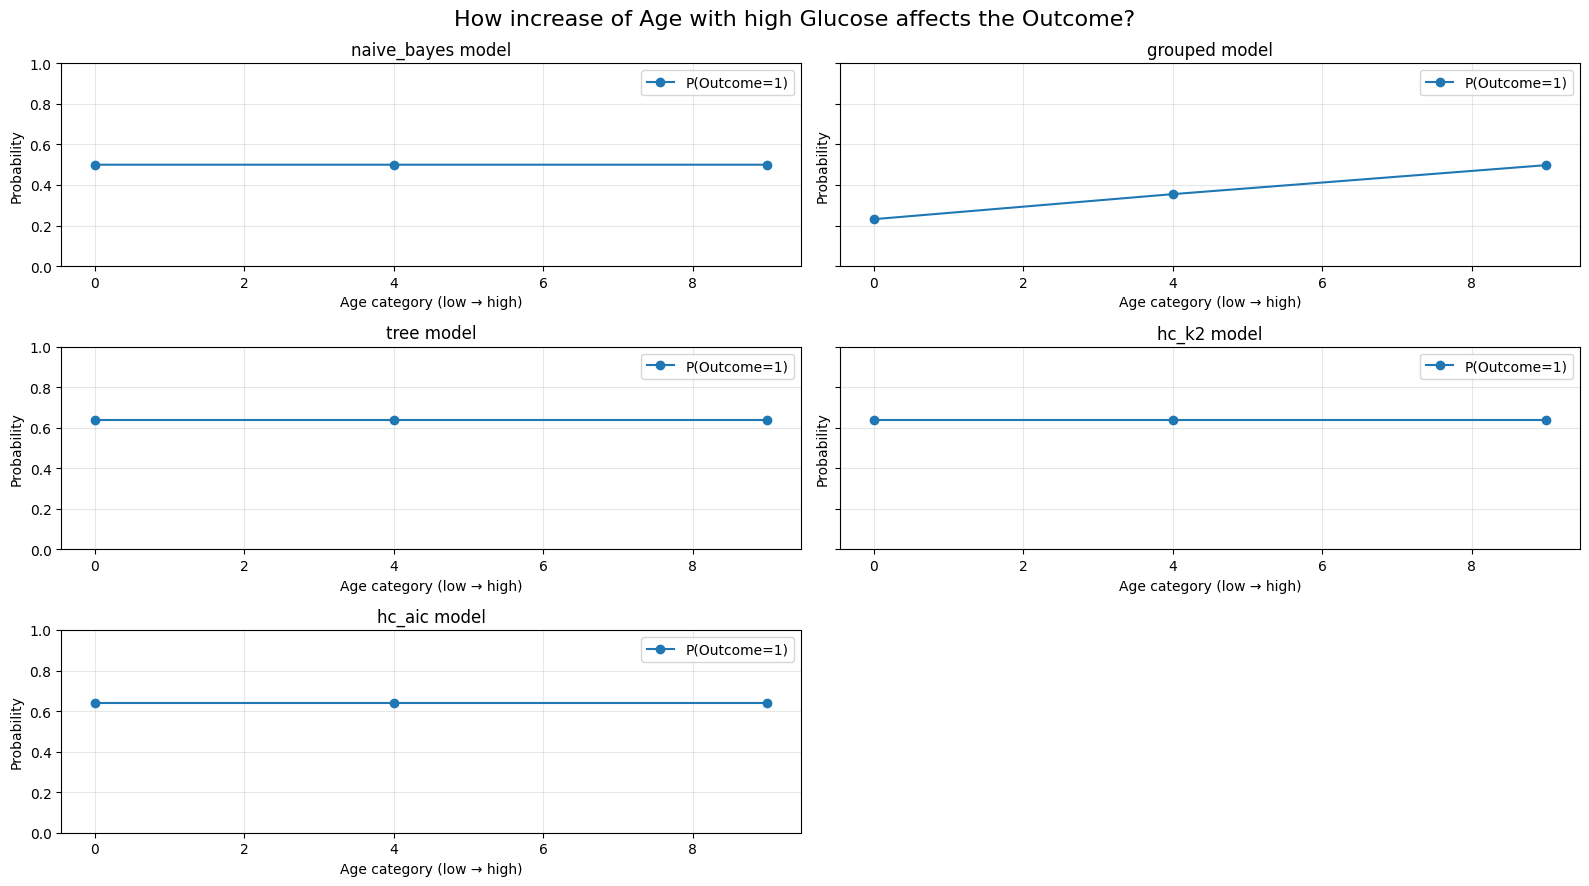


Change in P(Outcome=1) as Age increases (Glucose fixed high):

naive_bayes | start=0.500, end=0.500, Δ=+0.000 (+0.0%)
grouped    | start=0.231, end=0.498, Δ=+0.267 (+115.2%)
tree       | start=0.640, end=0.640, Δ=+0.000 (+0.0%)
hc_k2      | start=0.640, end=0.640, Δ=+0.000 (+0.0%)
hc_aic     | start=0.640, end=0.640, Δ=+0.000 (+0.0%)


In [194]:
title = "How increase of Age with high Glucose affects the Outcome?"
scores = [(0,8), (4,8), (9,8)]  # (Age, Glucose)

answer_scores = {}
x_values = [age for age, _ in scores]

for name, ve in inferences:
    answer_scores[name] = {}
    for age, glucose in scores:
        evidence = {"Age": age, "Glucose": glucose}
        answer_scores[name][(age, glucose)] = ve.query(
            ["Outcome"], evidence, show_progress=False
        ).values

# ---- Plot results ----
plot_result(
    answer_scores,
    'question1.png',
    title,
    x_values,
    x_label="Age category (low → high)"
)

# ---- Print compact change summary ----
print_outcome_change(
    answer_scores,
    variable_name="Age",
    condition_note="Glucose fixed high"
)


### Question 2: Does high BMI amplify diabetes risk for young individuals?

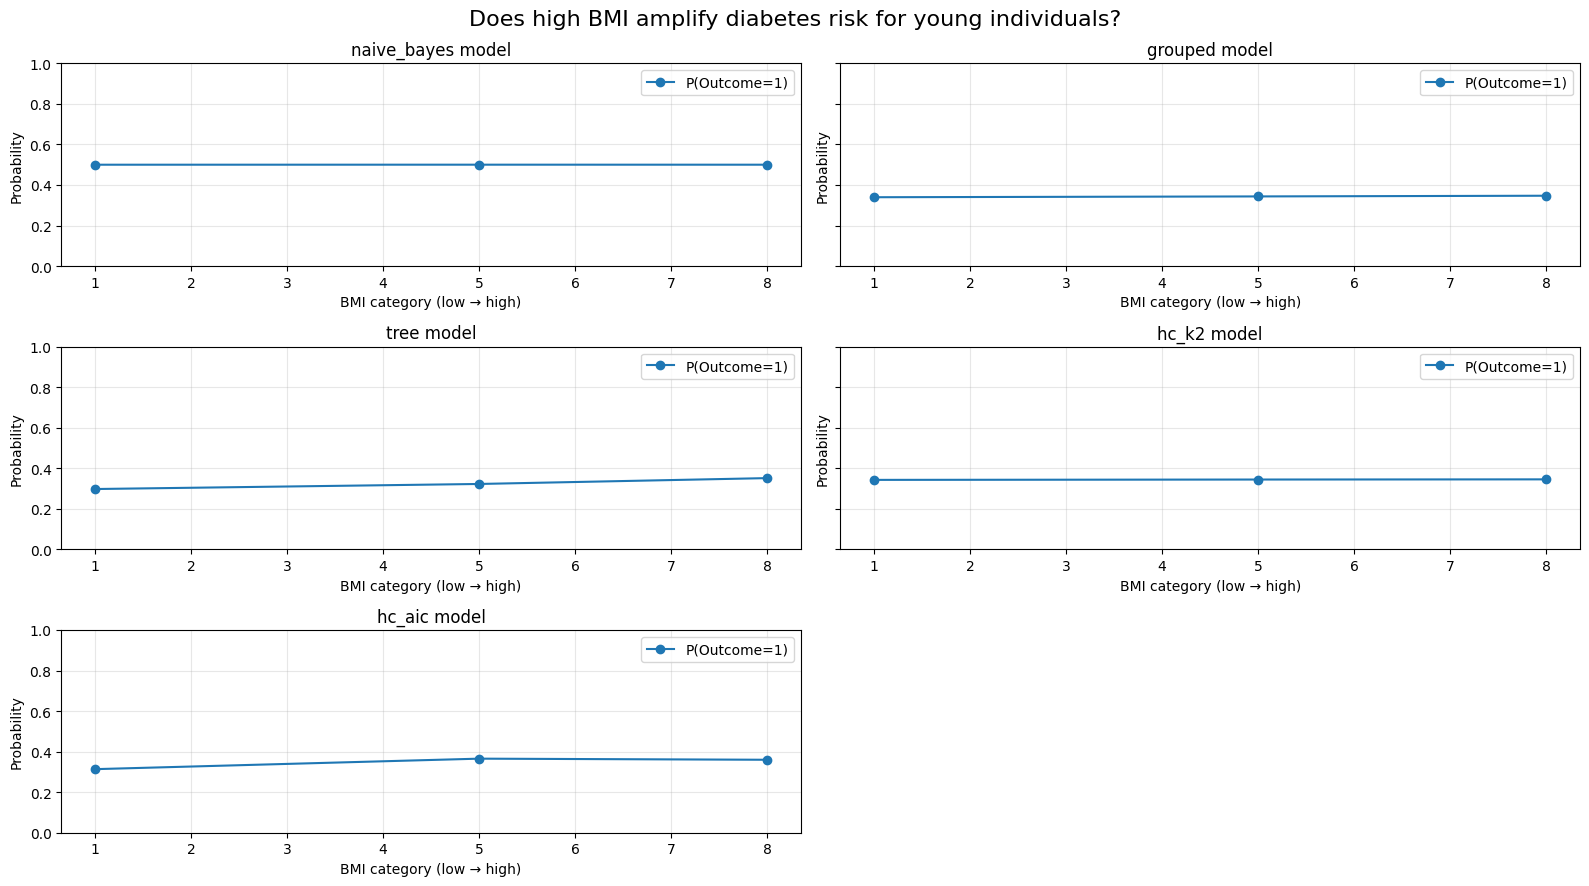


Change in P(Outcome=1) as BMI increases (Age fixed at low):

naive_bayes | start=0.500, end=0.500, Δ=+0.000 (+0.0%)
grouped    | start=0.339, end=0.347, Δ=+0.007 (+2.2%)
tree       | start=0.298, end=0.352, Δ=+0.054 (+18.1%)
hc_k2      | start=0.343, end=0.345, Δ=+0.003 (+0.8%)
hc_aic     | start=0.314, end=0.360, Δ=+0.046 (+14.8%)


In [195]:
# Question 2: Does high BMI amplify diabetes risk for young individuals?

title = "Does high BMI amplify diabetes risk for young individuals?"
scores = [(1, 1), (1, 5), (1, 8)]  # (Age, BMI)

answer_scores = {}
x_values = [bmi for _, bmi in scores]

for name, ve in inferences:
    answer_scores[name] = {}
    for age, bmi in scores:
        evidence = {"Age": age, "BMI": bmi}
        answer_scores[name][(age, bmi)] = ve.query(
            ["Outcome"], evidence, show_progress=False
        ).values

# ---- Plot ----
plot_result(
    answer_scores,
    'question2.png',
    title,
    x_values,
    x_label="BMI category (low → high)"
)

# ---- Summary ----
print_outcome_change(
    answer_scores,
    variable_name="BMI",
    condition_note="Age fixed at low"
)


### Question 3: Can low BMI reduce diabetes risk even at high Glucose levels?

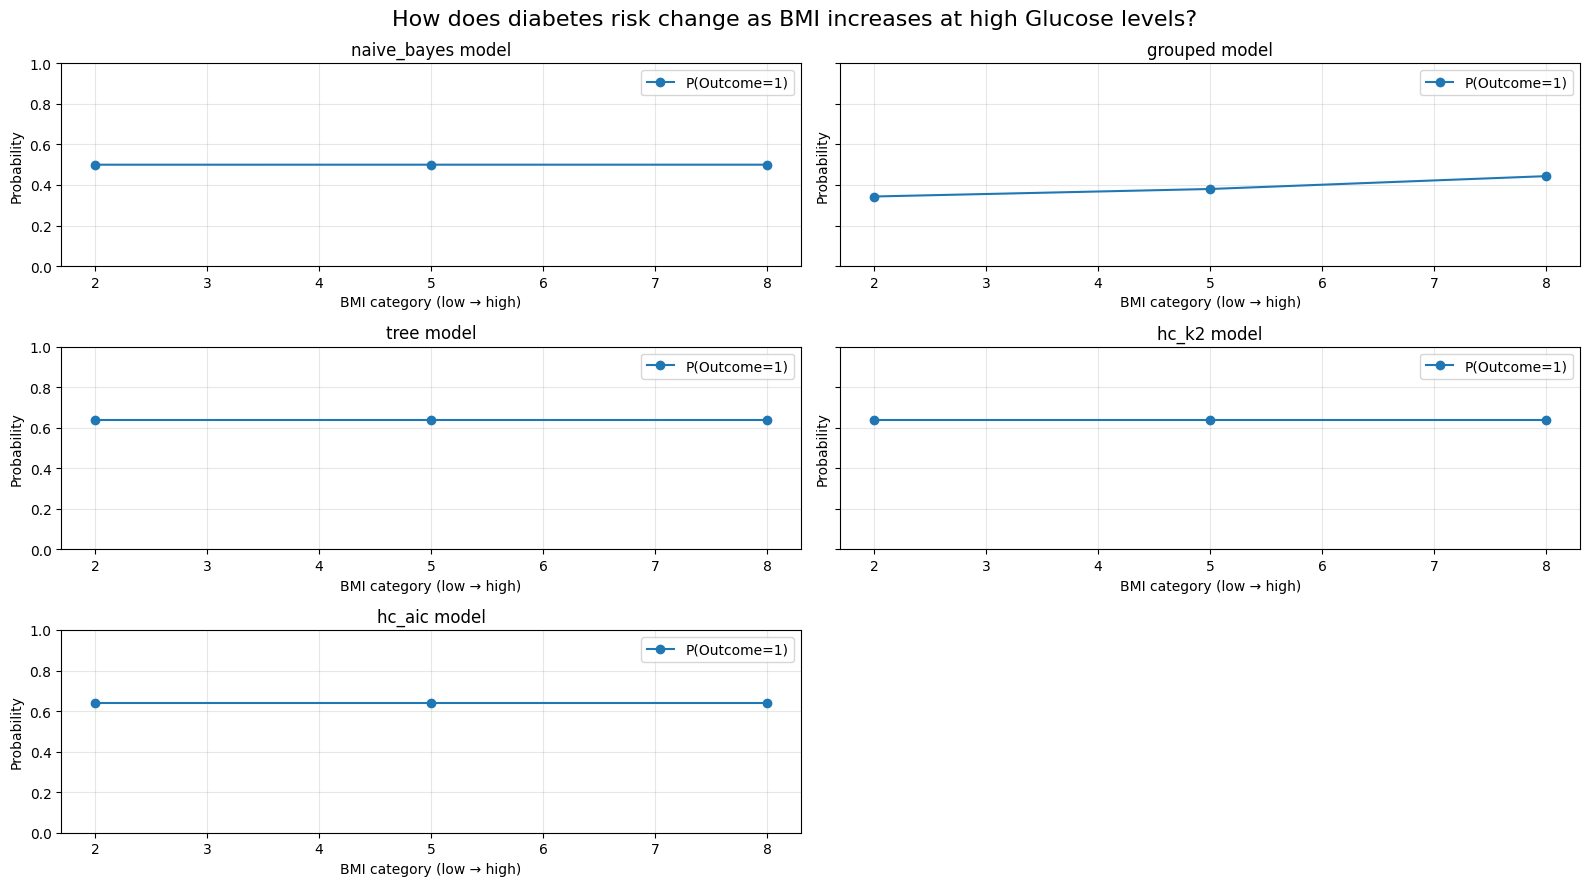


Change in P(Outcome=1) as BMI increases (Glucose fixed high):

naive_bayes | start=0.500, end=0.500, Δ=+0.000 (+0.0%)
grouped    | start=0.343, end=0.444, Δ=+0.100 (+29.3%)
tree       | start=0.640, end=0.640, Δ=+0.000 (+0.0%)
hc_k2      | start=0.640, end=0.640, Δ=+0.000 (+0.0%)
hc_aic     | start=0.640, end=0.640, Δ=+0.000 (+0.0%)


In [196]:
title ="How does diabetes risk change as BMI increases at high Glucose levels?"
scores = [(2, 8), (5, 8), (8, 8)]  # (BMI, Glucose)

answer_scores = {}
x_values = [bmi for bmi, _ in scores]

for name, ve in inferences:
    answer_scores[name] = {}
    for bmi, glucose in scores:
        evidence = {"BMI": bmi, "Glucose": glucose}
        answer_scores[name][(bmi, glucose)] = ve.query(
            ["Outcome"], evidence, show_progress=False
        ).values

# ---- Plot ----
plot_result(
    answer_scores,
    'question3.png',
    title,
    x_values,
    x_label="BMI category (low → high)"
)

# ---- Summary ----
print_outcome_change(
    answer_scores,
    variable_name="BMI",
    condition_note="Glucose fixed high"
)

### Question 4: Is Age or BMI the dominant risk factor when they disagree?

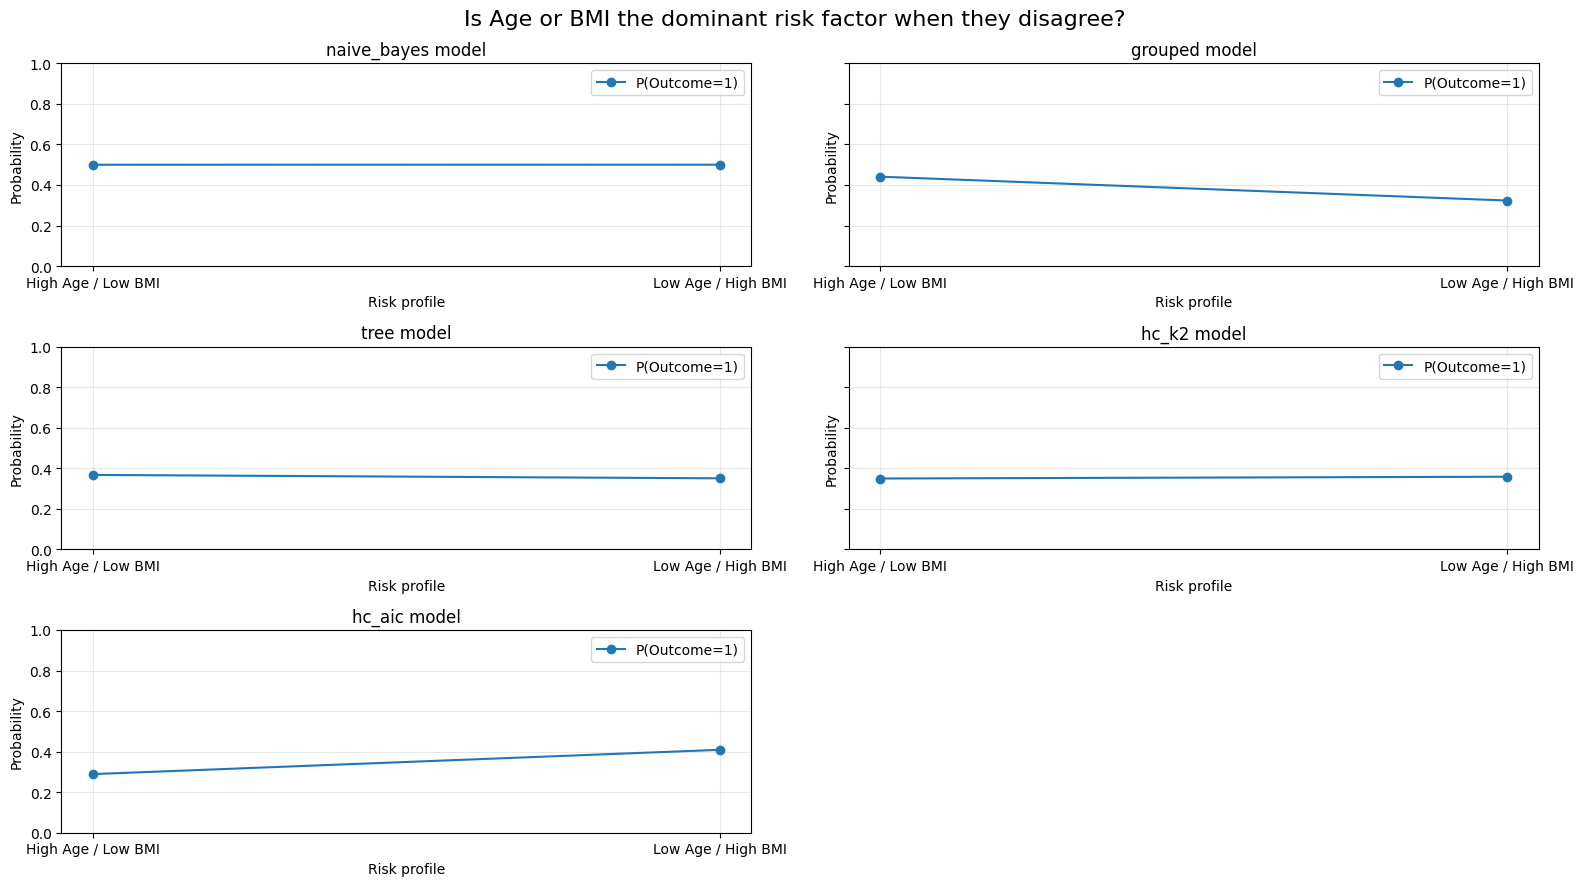


Change in P(Outcome=1) as Risk profile increases (Age vs BMI trade-off):

naive_bayes | start=0.500, end=0.500, Δ=+0.000 (+0.1%)
grouped    | start=0.441, end=0.323, Δ=-0.118 (-26.7%)
tree       | start=0.367, end=0.351, Δ=-0.017 (-4.6%)
hc_k2      | start=0.350, end=0.358, Δ=+0.009 (+2.5%)
hc_aic     | start=0.289, end=0.409, Δ=+0.120 (+41.5%)


In [197]:
# Question 4: Is Age or BMI the dominant risk factor when they disagree?

title = "Is Age or BMI the dominant risk factor when they disagree?"
scores = [
    (9, 2),  # High Age, Low BMI
    (2, 9)   # Low Age, High BMI
]

answer_scores = {}
x_values = ["High Age / Low BMI", "Low Age / High BMI"]

for name, ve in inferences:
    answer_scores[name] = {}
    for age, bmi in scores:
        evidence = {"Age": age, "BMI": bmi}
        answer_scores[name][(age, bmi)] = ve.query(
            ["Outcome"], evidence, show_progress=False
        ).values

# ---- Plot ----
plot_result(
    answer_scores,
    'question4.png',
    title,
    x_values,
    x_label="Risk profile"
)

# ---- Summary ----
print_outcome_change(
    answer_scores,
    variable_name="Risk profile",
    condition_note="Age vs BMI trade-off"
)


### Question 5: How does diabetes probability evolve across Age bins for average BMI?

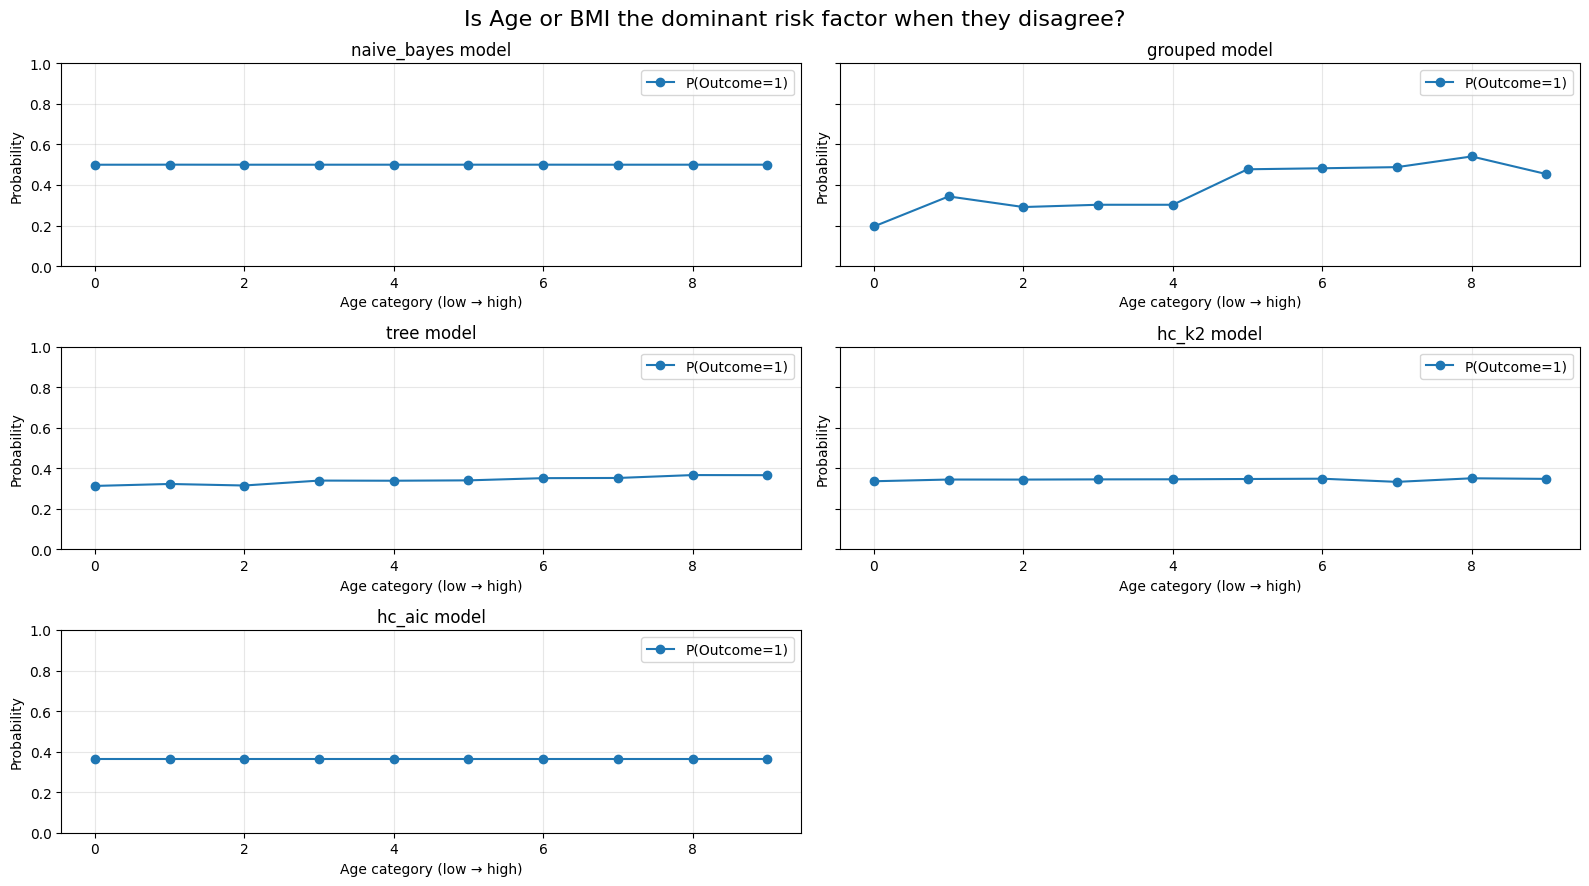


Change in P(Outcome=1) as Age increases (BMI fixed at average):

naive_bayes | start=0.500, end=0.500, Δ=+0.000 (+0.0%)
grouped    | start=0.195, end=0.454, Δ=+0.258 (+132.1%)
tree       | start=0.313, end=0.366, Δ=+0.053 (+16.9%)
hc_k2      | start=0.336, end=0.348, Δ=+0.012 (+3.5%)
hc_aic     | start=0.365, end=0.365, Δ=+0.000 (+0.0%)


In [198]:
ttile = "How does diabetes probability evolve across Age bins for average BMI?"
scores = [(age, 5) for age in range(10)]  # Age varies, BMI fixed at average

answer_scores = {}
x_values = [age for age, _ in scores]

for name, ve in inferences:
    answer_scores[name] = {}
    for age, bmi in scores:
        evidence = {"Age": age, "BMI": bmi}
        answer_scores[name][(age, bmi)] = ve.query(
            ["Outcome"], evidence, show_progress=False
        ).values

# ---- Plot ----
plot_result(
    answer_scores,
    'question5.png',
    title,
    x_values,
    x_label="Age category (low → high)"
)

# ---- Summary ----
print_outcome_change(
    answer_scores,
    variable_name="Age",
    condition_note="BMI fixed at average"
)

### Question 6: At what Glucose level does diabetes risk exceed 50% for elderly individuals?

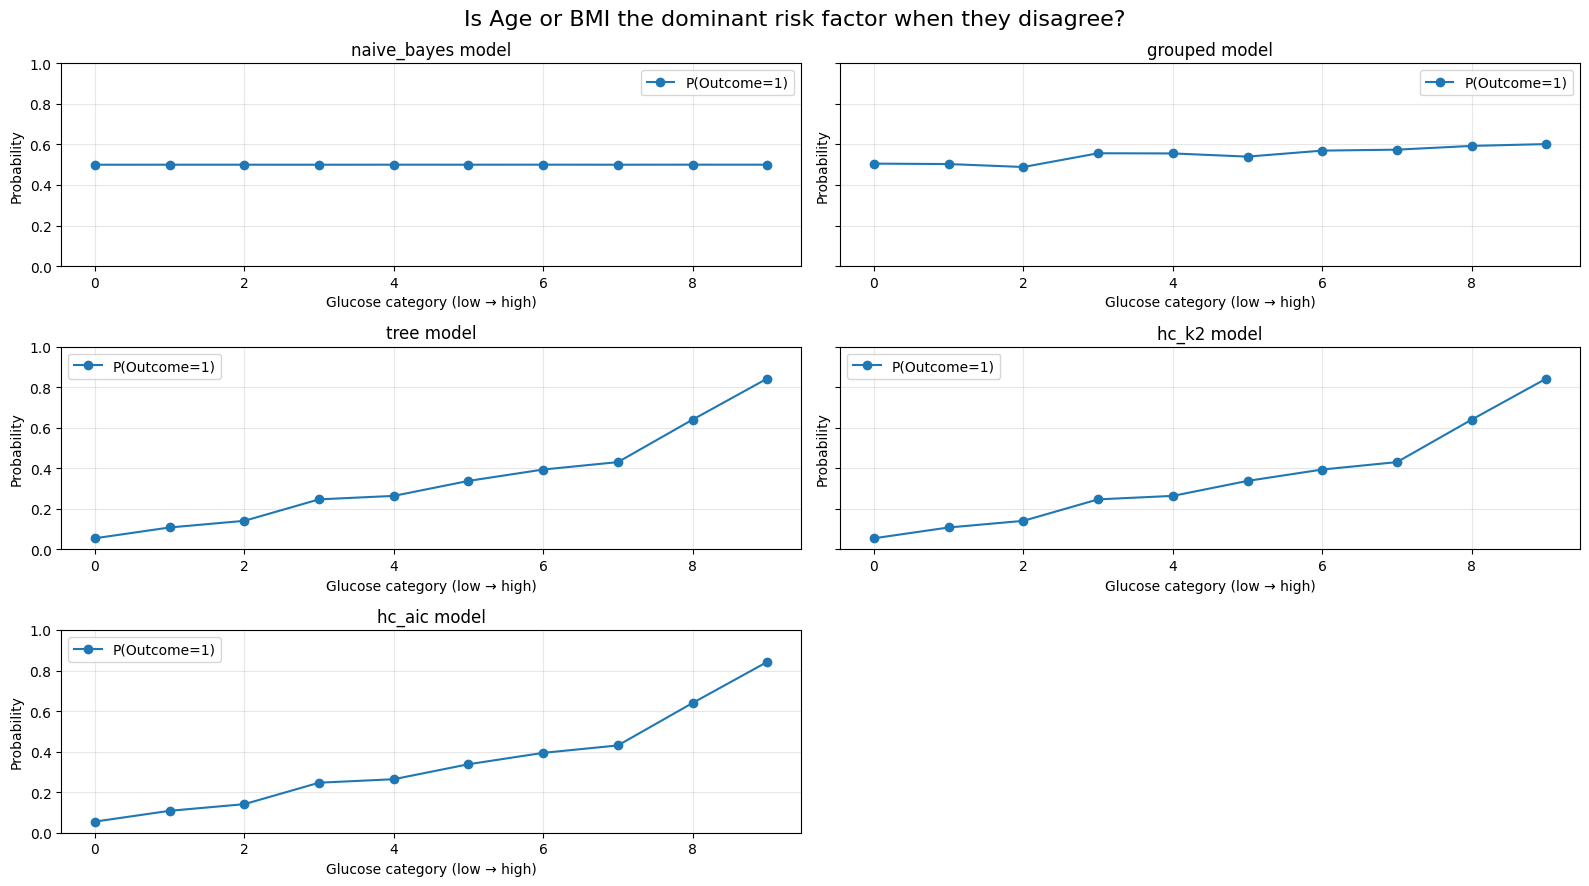


Change in P(Outcome=1) as Glucose increases (Age fixed at high (elderly)):

naive_bayes | start=0.500, end=0.500, Δ=+0.000 (+0.0%)
grouped    | start=0.505, end=0.602, Δ=+0.096 (+19.1%)
tree       | start=0.055, end=0.843, Δ=+0.788 (+1438.2%)
hc_k2      | start=0.055, end=0.843, Δ=+0.788 (+1438.2%)
hc_aic     | start=0.055, end=0.843, Δ=+0.788 (+1438.2%)


In [199]:
titile= "At what Glucose level does diabetes risk exceed 50% for elderly individuals?"
scores = [(8, g) for g in range(10)]  # Age fixed high (elderly), Glucose varies

answer_scores = {}
x_values = [glucose for _, glucose in scores]

for name, ve in inferences:
    answer_scores[name] = {}
    for age, glucose in scores:
        evidence = {"Age": age, "Glucose": glucose}
        answer_scores[name][(age, glucose)] = ve.query(
            ["Outcome"], evidence, show_progress=False
        ).values

# ---- Plot ----
plot_result(
    answer_scores,
    'question6.png',
    title,
    x_values,
    x_label="Glucose category (low → high)"
)

# ---- Summary ----
print_outcome_change(
    answer_scores,
    variable_name="Glucose",
    condition_note="Age fixed at high (elderly)"
)

### Question 7: Does moderate BMI increase diabetes risk for middle-aged individuals?

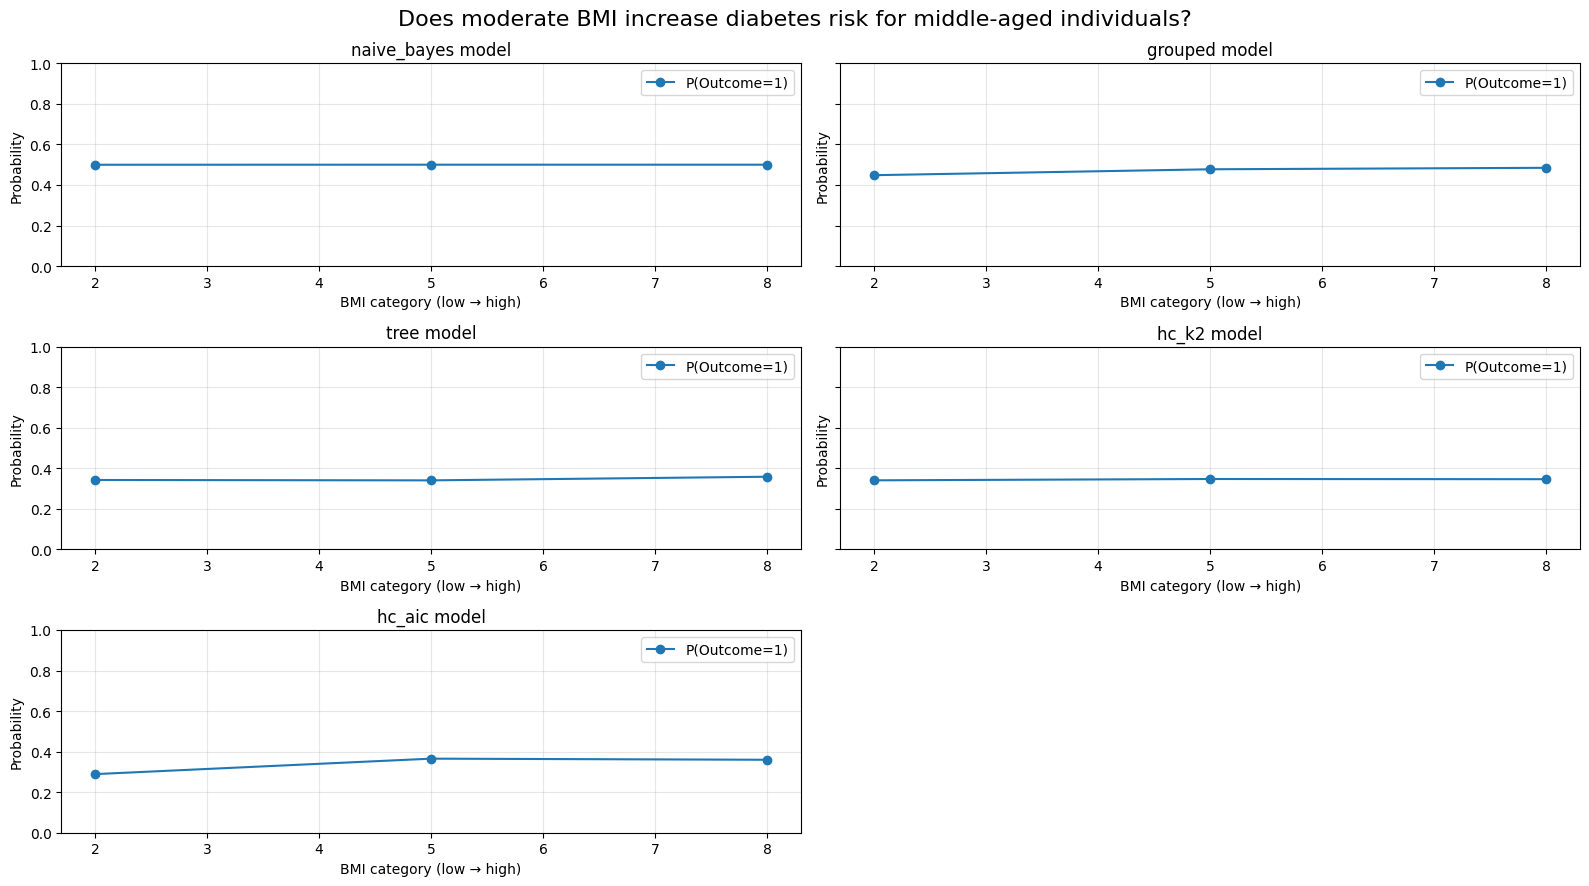


Change in P(Outcome=1) as BMI increases (Age fixed at middle):

naive_bayes | start=0.500, end=0.500, Δ=+0.000 (+0.0%)
grouped    | start=0.448, end=0.485, Δ=+0.036 (+8.1%)
tree       | start=0.342, end=0.358, Δ=+0.016 (+4.7%)
hc_k2      | start=0.341, end=0.346, Δ=+0.006 (+1.6%)
hc_aic     | start=0.289, end=0.360, Δ=+0.071 (+24.5%)


In [200]:
title = "Does moderate BMI increase diabetes risk for middle-aged individuals?"
scores = [(5, b) for b in [2, 5, 8]]  # Age fixed at middle, BMI varies

answer_scores = {}
x_values = [bmi for _, bmi in scores]

for name, ve in inferences:
    answer_scores[name] = {}
    for age, bmi in scores:
        evidence = {"Age": age, "BMI": bmi}
        answer_scores[name][(age, bmi)] = ve.query(
            ["Outcome"], evidence, show_progress=False
        ).values

# ---- Plot ----
plot_result(
    answer_scores,
    'question7.png',
    title,
    x_values,
    x_label="BMI category (low → high)"
)

# ---- Summary ----
print_outcome_change(
    answer_scores,
    variable_name="BMI",
    condition_note="Age fixed at middle"
)

### Question 8: Is high Glucose alone sufficient to induce high diabetes risk?

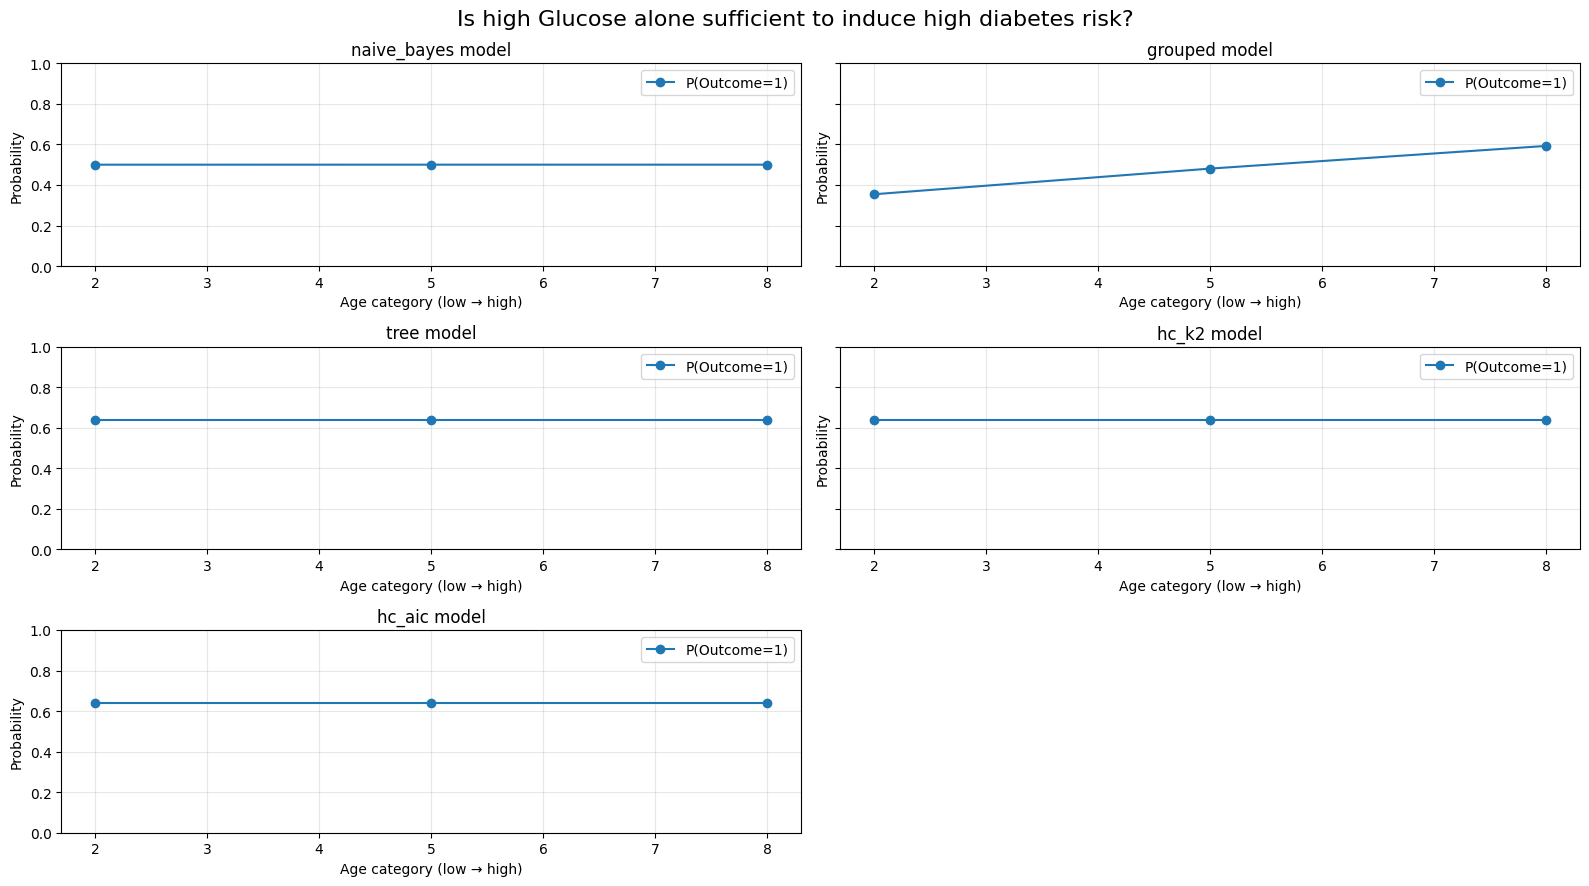


Change in P(Outcome=1) as Age increases (Glucose fixed high):

naive_bayes | start=0.500, end=0.500, Δ=+0.000 (+0.0%)
grouped    | start=0.354, end=0.593, Δ=+0.239 (+67.3%)
tree       | start=0.640, end=0.640, Δ=+0.000 (+0.0%)
hc_k2      | start=0.640, end=0.640, Δ=+0.000 (+0.0%)
hc_aic     | start=0.640, end=0.640, Δ=+0.000 (+0.0%)


In [201]:
title = "Is high Glucose alone sufficient to induce high diabetes risk?"
scores = [(2, 8), (5, 8), (8, 8)]  # Age varies, Glucose fixed high

answer_scores = {}
x_values = [age for age, _ in scores]

for name, ve in inferences:
    answer_scores[name] = {}
    for age, glucose in scores:
        evidence = {"Age": age, "Glucose": glucose}
        answer_scores[name][(age, glucose)] = ve.query(
            ["Outcome"], evidence, show_progress=False
        ).values

# ---- Plot ----
plot_result(
    answer_scores,
    'question8.png',
    title,
    x_values,
    x_label="Age category (low → high)"
)

# ---- Summary ----
print_outcome_change(
    answer_scores,
    variable_name="Age",
    condition_note="Glucose fixed high"
)

### Question 9: How does diabetes risk differ between young-obese and old-lean individuals?

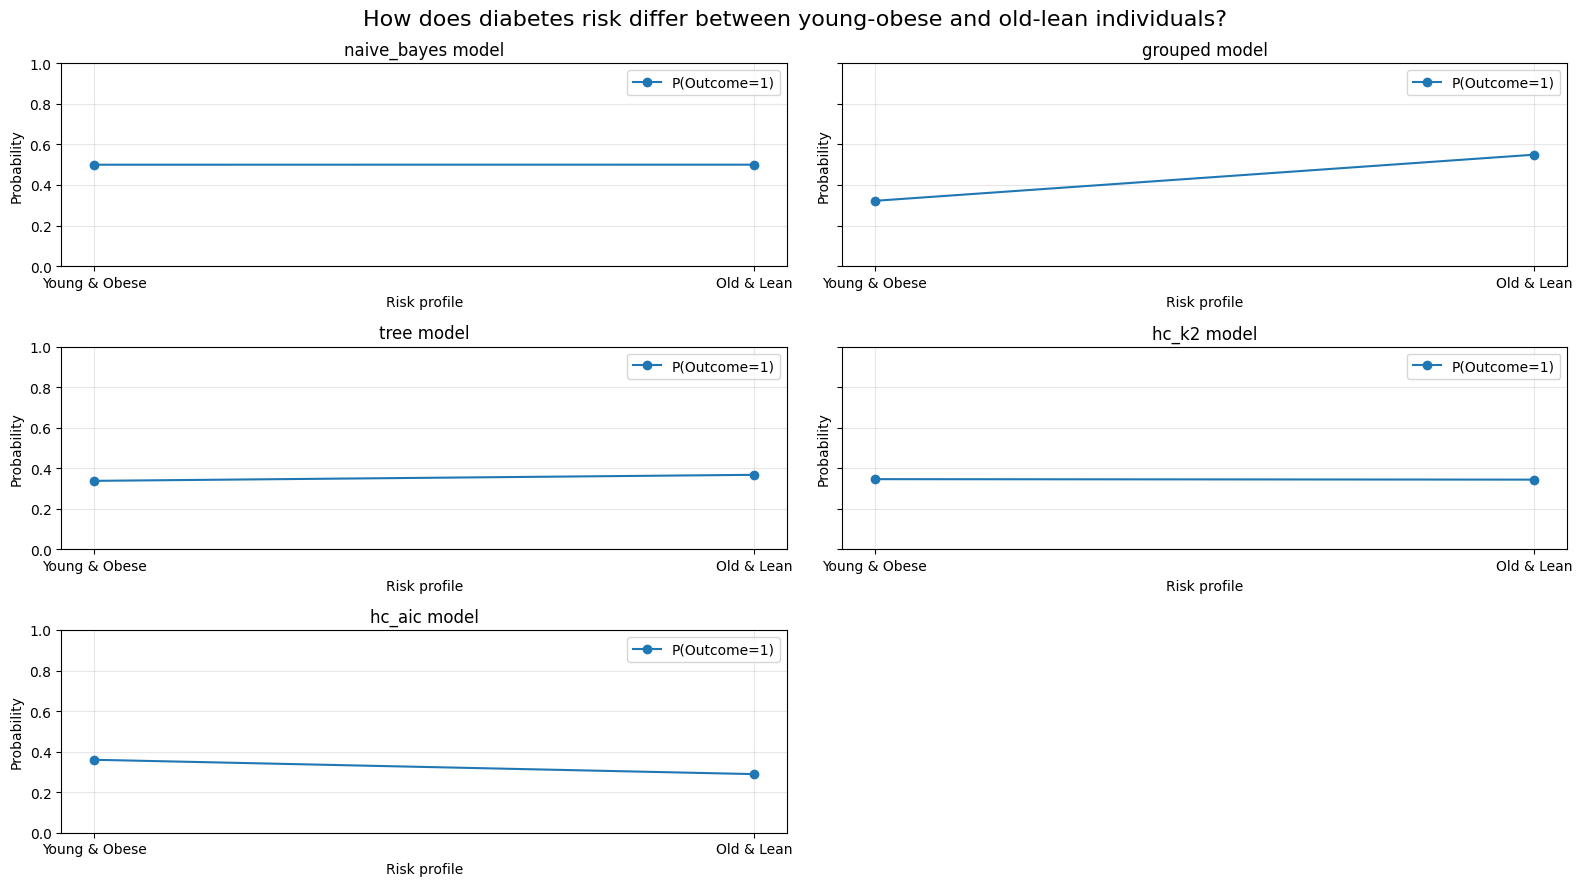


Change in P(Outcome=1) as Risk profile increases (Young-obese vs Old-lean):

naive_bayes | start=0.500, end=0.500, Δ=+0.000 (+0.0%)
grouped    | start=0.322, end=0.549, Δ=+0.228 (+70.8%)
tree       | start=0.338, end=0.368, Δ=+0.030 (+8.8%)
hc_k2      | start=0.346, end=0.344, Δ=-0.002 (-0.7%)
hc_aic     | start=0.360, end=0.289, Δ=-0.071 (-19.7%)


In [202]:
title = "How does diabetes risk differ between young-obese and old-lean individuals?"
scores = [
    {"Age": 2, "BMI": 8},  # Young, obese
    {"Age": 8, "BMI": 2}   # Old, lean
]

answer_scores = {}
x_values = ["Young & Obese", "Old & Lean"]

for name, ve in inferences:
    answer_scores[name] = {}
    for s in scores:
        answer_scores[name][tuple(s.items())] = ve.query(
            ["Outcome"], s, show_progress=False
        ).values

# ---- Plot ----
plot_result(
    answer_scores,
    'question9.png',
    title,
    x_values,
    x_label="Risk profile"
)

# ---- Summary ----
print_outcome_change(
    answer_scores,
    variable_name="Risk profile",
    condition_note="Young-obese vs Old-lean"
)

### Question 10: Which age group shows the highest sensitivity to BMI changes?

#### Question 10a — Young group

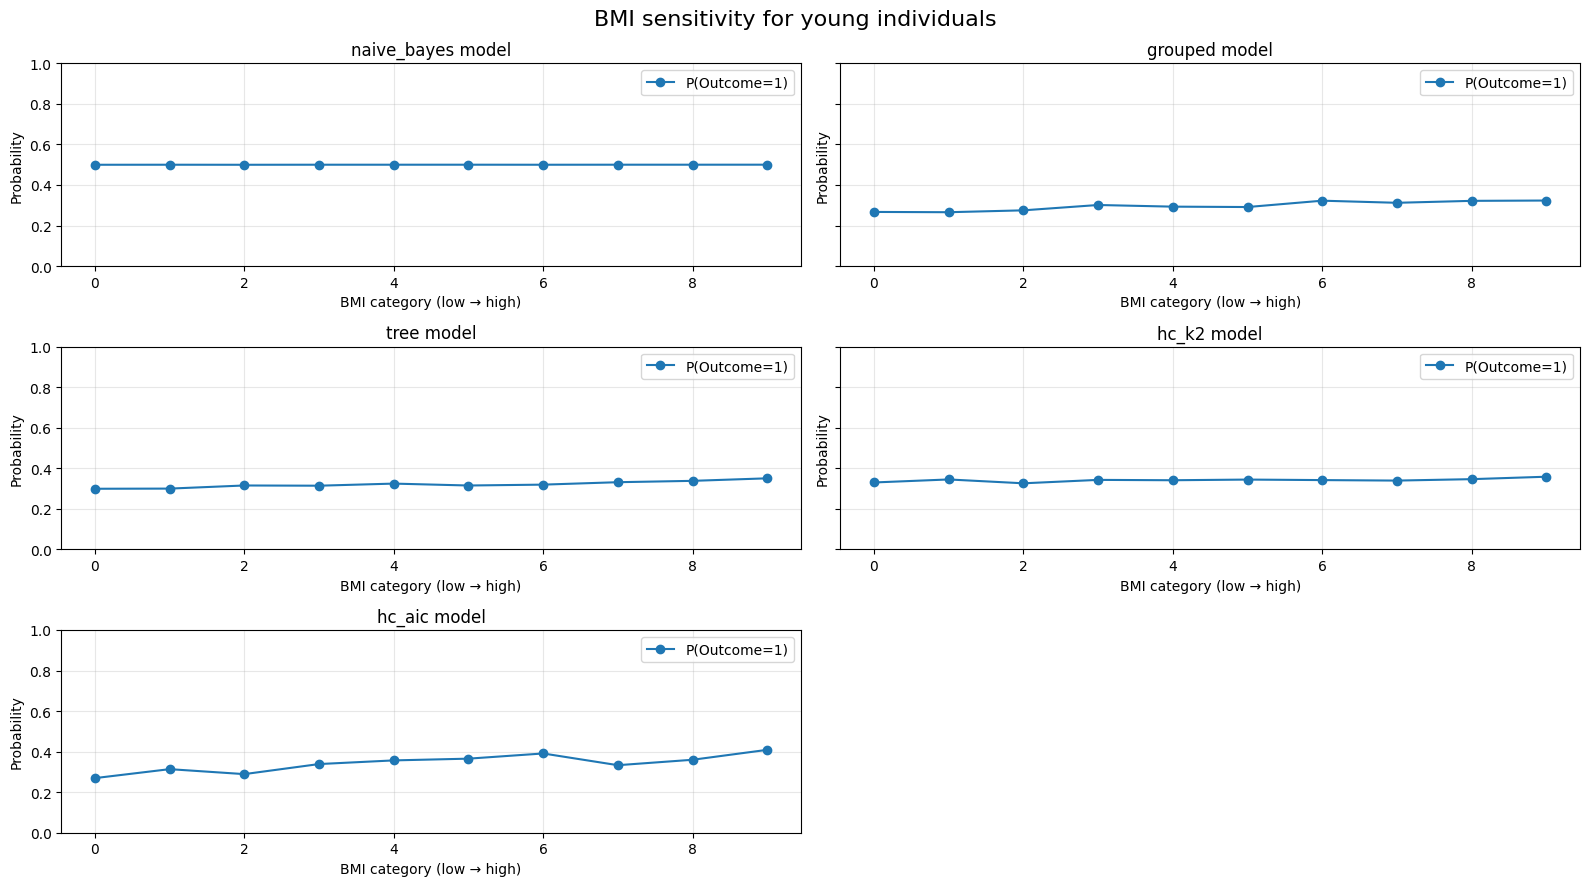


Change in P(Outcome=1) as BMI increases (Age fixed at young):

naive_bayes | start=0.500, end=0.500, Δ=+0.000 (+0.1%)
grouped    | start=0.267, end=0.323, Δ=+0.056 (+21.1%)
tree       | start=0.299, end=0.351, Δ=+0.051 (+17.2%)
hc_k2      | start=0.330, end=0.358, Δ=+0.028 (+8.6%)
hc_aic     | start=0.269, end=0.409, Δ=+0.140 (+51.8%)


In [203]:
title = "BMI sensitivity for young individuals"
scores = [(2, b) for b in range(10)]  # Age = 2, BMI varies

answer_scores = {}
x_values = [b for _, b in scores]

for name, ve in inferences:
    answer_scores[name] = {}
    for age, bmi in scores:
        evidence = {"Age": age, "BMI": bmi}
        answer_scores[name][(age, bmi)] = ve.query(
            ["Outcome"], evidence, show_progress=False
        ).values

plot_result(
    answer_scores,
    'question10_young.png',
    title,
    x_values,
    x_label="BMI category (low → high)"
)

print_outcome_change(
    answer_scores,
    variable_name="BMI",
    condition_note="Age fixed at young"
)

#### Question 10b — Old group

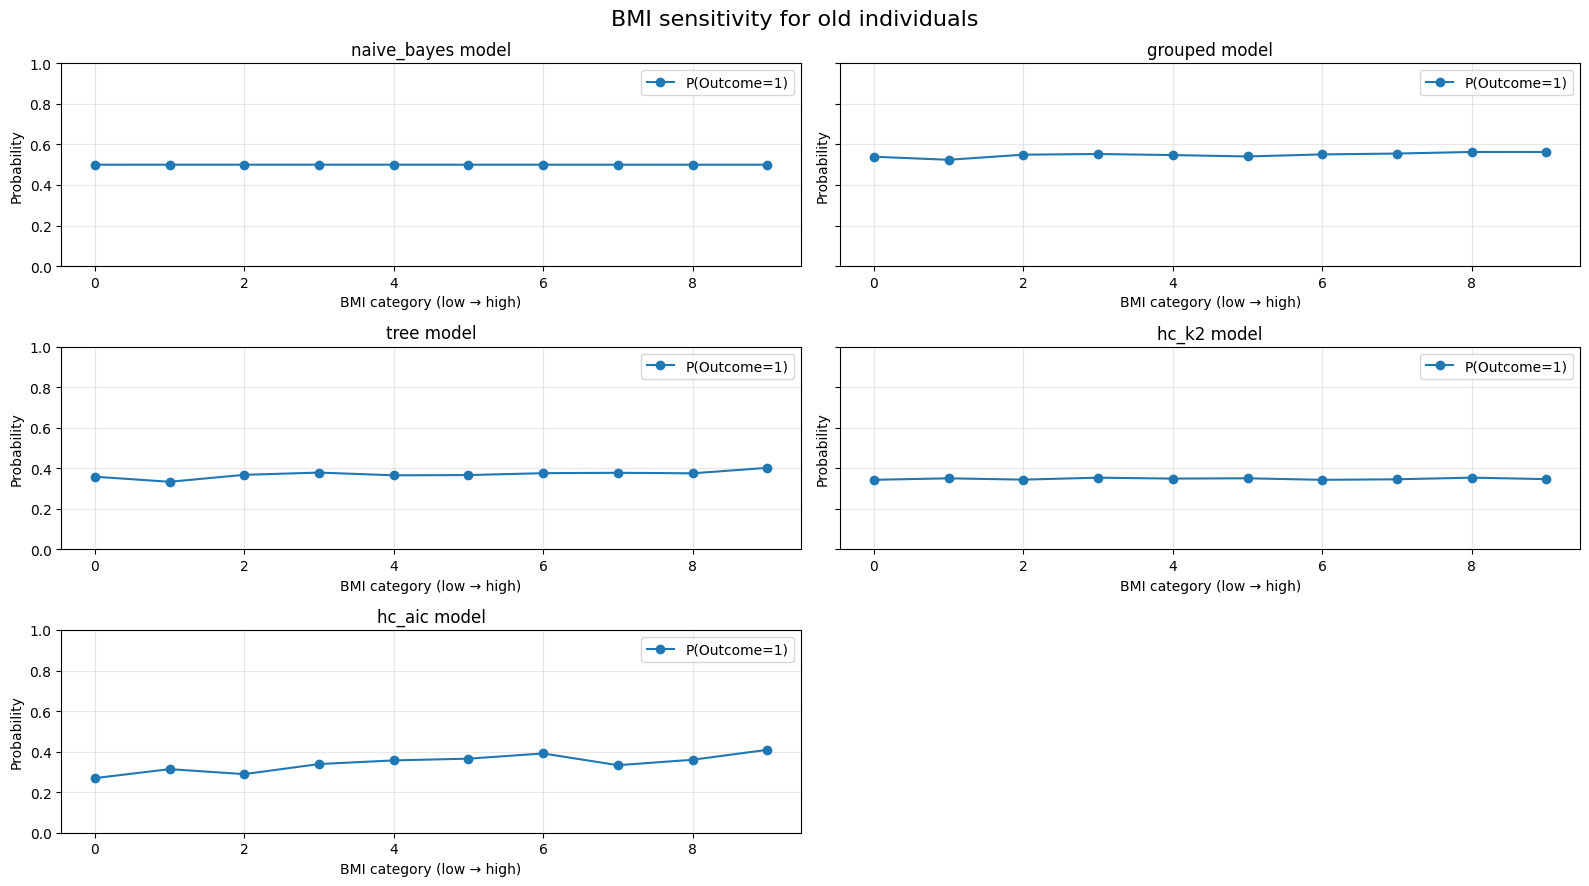


Change in P(Outcome=1) as BMI increases (Age fixed at old):

naive_bayes | start=0.500, end=0.500, Δ=+0.000 (+0.0%)
grouped    | start=0.539, end=0.563, Δ=+0.023 (+4.3%)
tree       | start=0.358, end=0.402, Δ=+0.044 (+12.2%)
hc_k2      | start=0.343, end=0.347, Δ=+0.003 (+1.0%)
hc_aic     | start=0.269, end=0.409, Δ=+0.140 (+51.8%)


In [204]:
title = "BMI sensitivity for old individuals"
scores = [(8, b) for b in range(10)]  # Age = 8, BMI varies

answer_scores = {}
x_values = [b for _, b in scores]

for name, ve in inferences:
    answer_scores[name] = {}
    for age, bmi in scores:
        evidence = {"Age": age, "BMI": bmi}
        answer_scores[name][(age, bmi)] = ve.query(
            ["Outcome"], evidence, show_progress=False
        ).values

plot_result(
    answer_scores,
    'question10_old.png',
    title,
    x_values,
    x_label="BMI category (low → high)"
)

print_outcome_change(
    answer_scores,
    variable_name="BMI",
    condition_note="Age fixed at old"
)

### Question 11 : Does diabetes risk increase with the number of pregnancies when genetic risk is high?

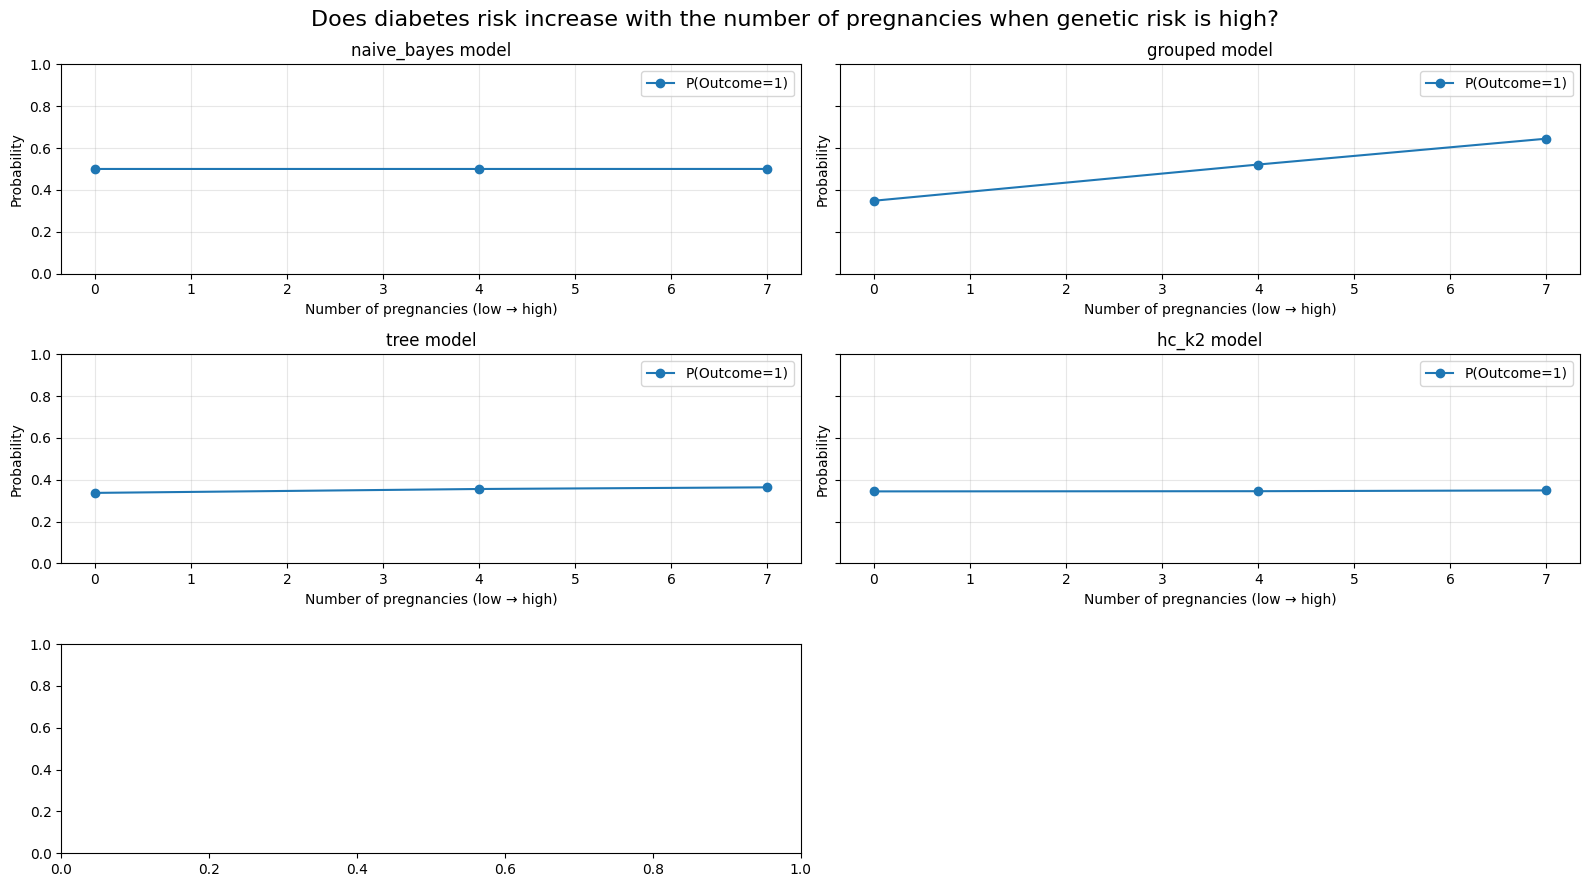


Change in P(Outcome=1) as Pregnancies increases (Genetic risk fixed high):

naive_bayes | start=0.500, end=0.500, Δ=+0.000 (+0.0%)
grouped    | start=0.348, end=0.645, Δ=+0.297 (+85.2%)
tree       | start=0.337, end=0.364, Δ=+0.027 (+7.9%)
hc_k2      | start=0.344, end=0.349, Δ=+0.005 (+1.4%)


In [205]:
title = "Does diabetes risk increase with the number of pregnancies when genetic risk is high?"
scores = [(0, 8), (4, 8), (7, 8)]  # (Pregnancies, DiabetesPedigreeFunction)

answer_scores = {}
x_values = [preg for preg, _ in scores]

for name, ve in inferences:
    if not ("DiabetesPedigreeFunction" in ve.model.nodes() and "Pregnancies" in ve.model.nodes()):
            continue
    answer_scores[name] = {}
    for preg, dpf in scores:
        evidence = {
            "Pregnancies": preg,
            "DiabetesPedigreeFunction": dpf
        }
        answer_scores[name][(preg, dpf)] = ve.query(
            ["Outcome"], evidence, show_progress=False
        ).values

# ---- Plot ----
plot_result(
    answer_scores,
    'question11.png',
    title,
    x_values,
    x_label="Number of pregnancies (low → high)"
)

# ---- Summary ----
print_outcome_change(
    answer_scores,
    variable_name="Pregnancies",
    condition_note="Genetic risk fixed high"
)

### Question 12: Is genetic risk (DPF) alone sufficient to produce high diabetes probability?

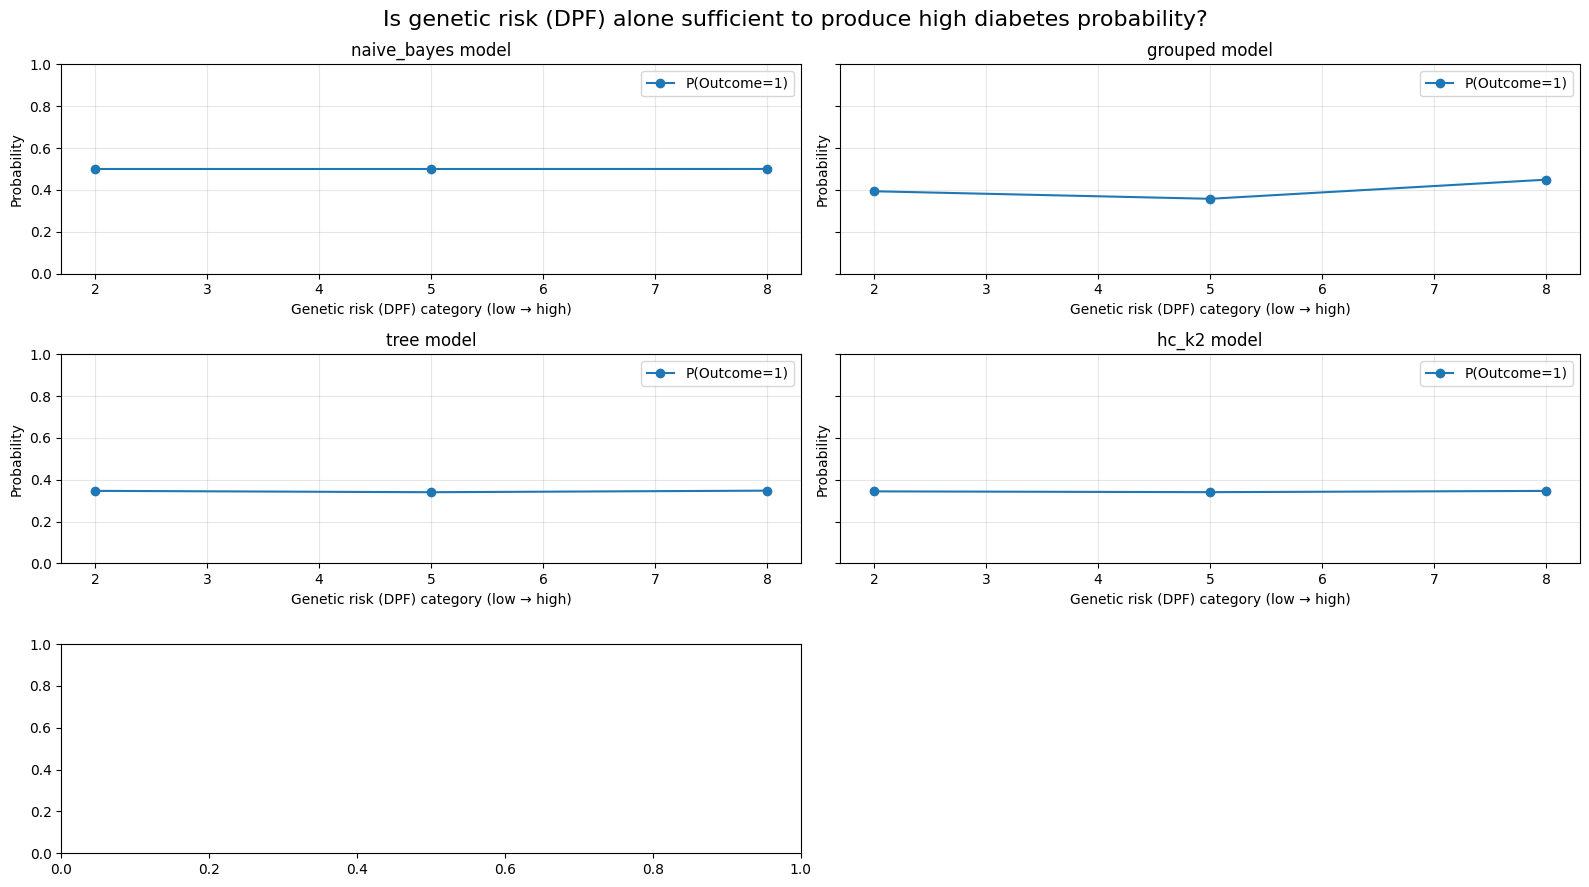


Change in P(Outcome=1) as Genetic risk (DPF) increases (DPF varies alone):

naive_bayes | start=0.500, end=0.500, Δ=+0.000 (+0.0%)
grouped    | start=0.393, end=0.449, Δ=+0.055 (+14.1%)
tree       | start=0.347, end=0.348, Δ=+0.001 (+0.3%)
hc_k2      | start=0.344, end=0.347, Δ=+0.002 (+0.6%)


In [206]:
title = "Is genetic risk (DPF) alone sufficient to produce high diabetes probability?"
scores = [(2,), (5,), (8,)]  # DiabetesPedigreeFunction varies

answer_scores = {}
x_values = [dpf for (dpf,) in scores]

for name, ve in inferences:
    if not ("DiabetesPedigreeFunction" in ve.model.nodes() and "Pregnancies" in ve.model.nodes()):
            continue
    answer_scores[name] = {}
    for (dpf,) in scores:
        evidence = {"DiabetesPedigreeFunction": dpf}
        answer_scores[name][(dpf,)] = ve.query(
            ["Outcome"], evidence, show_progress=False
        ).values

# ---- Plot ----
plot_result(
    answer_scores,
    'question12.png',
    title,
    x_values,
    x_label="Genetic risk (DPF) category (low → high)"
)

# ---- Summary ----
print_outcome_change(
    answer_scores,
    variable_name="Genetic risk (DPF)",
    condition_note="DPF varies alone"
)

# Bayesian Network Analysis of Diabetes Risk: Updated Results and Comparative Analysis

---

## 1. Overview
Following an initial exploratory phase, the modeling pipeline was refined to improve both data quality and inference reliability. This analysis focuses on a streamlined preprocessing strategy and a reduced, more interpretable set of Bayesian Network models applied to the **Indian Diabetes dataset**.

**Key updates in this iteration:**
* **Feature Selection**: Removal of `SkinThickness` due to high missingness and weak correlation with the outcome.
* **Data Cleaning**: Dropping rows with excessive missing values instead of applying aggressive imputation.
* **Refined Discretization**: Transitioned to **Quantile-based discretization** after column-wise experimentation with granularity.
* **Model Focus**: Evaluation of five structures, with a specific focus on the limitations of manual structures versus automated learning.

---

## 2. Final Preprocessing Strategy
Based on correlation analysis and pairwise plots, the following pipeline was adopted to ensure stable Conditional Probability Distributions (CPDs):

| Step | Action taken | Rationale |
| :--- | :--- | :--- |
| **Missing Data** | Dropped rows; excluded `SkinThickness`. | Preserves statistical integrity; avoids imputation bias. |
| **Discretization** | Quantile-based binning. | Preserves ordinal structure and maintains stable probability estimates. |

---

## 3. Bayesian Network Models Evaluated
The following structures were trained using **Maximum Likelihood Estimation (MLE)**:

1. **Naive Bayes (Basic)**: Assumes all features are conditionally independent given the outcome.
2. **Grouped Model**: Incorporates domain-informed groupings but is limited by manual structural assumptions.
3. **Tree-Based Model**: Learned via Tree Search to identify hierarchical dependency paths.
4. **Hill Climbing (K2 Score)**: A score-based model favoring strong, often denser dependencies.
5. **Hill Climbing (AIC Score)**: A penalized likelihood approach favoring simpler, regularized graphs.

---

## 4. Inference Results by Model Type

### 1. Naive Bayes Model
Produced nearly flat probability curves (~0.5) across all questions. 
* **Conclusion**: Serves only as a baseline; it is functionally useless for substantive diabetes risk interpretation.

### 2. Grouped Model (Manual Structure)
While intended to provide a domain-informed baseline, the Grouped model proved **insufficient** for this dataset.
* **Limitations**: It failed to capture the non-linear nuances between metabolic markers.
* **Sensitivity**: Showed less responsiveness to evidence compared to learned structures, often producing overly conservative or rigid risk estimates that do not align with the data's underlying complexity.

### 3. Tree-Based Model
* **Performance**: Showed strong sensitivity but often resulted in "hard" probability shifts.
* **Risk**: High risk of over-simplifying the causal paths by forcing a single-parent constraint on the nodes.

### 4. Hill Climbing with K2 Score
* **Performance**: Produced expressive and dense structures. 
* **Observation**: Highly sensitive to Age and BMI changes, but often showed **overconfidence**, with probabilities jumping sharply due to the high number of dependencies learned.

### 5. Hill Climbing with AIC Score
* **Performance**: Provided the most balanced and regularized results.
* **Observation**: Successfully identified the dominant influence of Glucose while still allowing Age and BMI to influence the risk score in a stable, non-extreme manner.

---

## 5. Comparative Performance Table

| Model | Sensitivity | Structural Integrity | Clinical Utility | Verdict |
| :--- | :--- | :--- | :--- | :--- |
| **Naive Bayes** | Very Low | Low | Very Low | **Failure**: Cannot propagate evidence. |
| **Grouped** | Low | Medium | Low | **Insufficient**: Too rigid to capture data nuances. |
| **Tree** | High | Medium | Medium | **Informative**: Useful but potentially over-simplistic. |
| **HC (K2)** | Very High | High | Medium | **Aggressive**: Powerful but prone to overconfidence. |
| **HC (AIC)** | High | High | Very High | **Optimal**: Best balance of complexity and accuracy. |

---

## 6. Final Conclusions
* **Manual vs. Automated**: The **Grouped model is not good enough** for accurate clinical modeling in this context; automated structure learning is required to discover the true conditional dependencies in the data.
* **Preprocessing Impact**: Dropping `SkinThickness` and using Quantile discretization was essential for clear results, as it allowed the Hill Climbing models to focus on the most high-impact features.
* **Scoring Functions**: **AIC scoring** outperformed K2 by providing a regularized graph that avoids the "noise" of overly dense networks.
* **Final Summary**: Bayesian Network inference quality is driven primarily by **structured automated learning (Hill Climbing)** and careful data preparation, as manual assumptions (Grouped/Naive) fail to meet the complexity of the diabetes risk profile.

---

## Bayesian Network Classification using Hill Climbing

This section evaluates Bayesian Network classifiers learned via **score-based structure learning**
using the **Hill Climbing** algorithm with two alternative scoring functions:

- **AIC (Akaike Information Criterion)**
- **K2 Score**

The goal is to classify the binary variable **Outcome** using probabilistic inference and to compare
model performance under:
- Train/Test split
- K-fold cross-validation

All models are trained on discretized data and evaluated using classification accuracy.


In [216]:
X = df_quantile.drop(columns=['Outcome'])
y = df_quantile['Outcome']

train_df, test_df = train_test_split(
    df_quantile,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f'Training set size: {train_df.shape[0]} samples')
print(f'Testing set size: {test_df.shape[0]} samples')


Training set size: 579 samples
Testing set size: 145 samples


In [217]:

def train_hc_model(train_data, score_type='aic'):
    hc = HillClimbSearch(train_data)

    if score_type == 'aic':
        score = AIC(train_data)
    elif score_type == 'k2':
        score = K2(train_data)
    else:
        raise ValueError("Score must be 'aic' or 'k2'")

    model = hc.estimate(scoring_method=score, show_progress=False)
    bn = DiscreteBayesianNetwork(model.edges())
    bn.fit(train_data, estimator=MaximumLikelihoodEstimator)

    return bn


In [218]:
def predict_bn(model, test_data):
    infer = VariableElimination(model)
    y_true, y_pred = [], []

    for _, row in test_data.iterrows():
        evidence = row.drop('Outcome').to_dict()
        true_label = row['Outcome']

        prob = infer.query(['Outcome'], evidence, show_progress=False)
        pred_label = np.argmax(prob.values)

        y_true.append(true_label)
        y_pred.append(pred_label)

    return accuracy_score(y_true, y_pred)


In [219]:
results = {}

for score in ['aic', 'k2']:
    model = train_hc_model(train_df, score)
    acc = predict_bn(model, test_df)
    results[score.upper()] = acc
    print(f"Hill Climbing ({score.upper()}) Accuracy: {acc:.4f}")


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'Insulin': 'N', 'BMI': 'N', 'DiabetesPedigreeFunction': 'N', 'Age': 'N', 'Outcome': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'Insulin': 'N', 'BMI': 'N', 'DiabetesPedigreeFunction': 'N', 'Age': 'N', 'Outcome': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'Insulin': 'N', 'BMI': 'N', 'DiabetesPedigreeFunction': 'N', 'Age': 'N', 'Outcome': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'Insulin': 'N', 'BMI': 'N', 'DiabetesPedigreeFunction': 'N', 'Age': 'N', 'Out

Hill Climbing (AIC) Accuracy: 0.6897
Hill Climbing (K2) Accuracy: 0.6966


## K-Fold Cross-Validation

To ensure robustness, 5-fold cross-validation is performed.
For each fold:
- A Bayesian Network is learned using Hill Climbing
- CPDs are estimated using Maximum Likelihood
- Outcome is predicted using probabilistic inference


In [225]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

cv_results = {'AIC': [], 'K2': []}

for train_idx, test_idx in kf.split(df_quantile):
    train_data = df_quantile.iloc[train_idx]
    test_data = df_quantile.iloc[test_idx]

    for score in ['aic', 'k2']:
        model = train_hc_model(train_data, score)
        acc = predict_bn(model, test_data)
        cv_results[score.upper()].append(acc)


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'Insulin': 'N', 'BMI': 'N', 'DiabetesPedigreeFunction': 'N', 'Age': 'N', 'Outcome': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'Insulin': 'N', 'BMI': 'N', 'DiabetesPedigreeFunction': 'N', 'Age': 'N', 'Outcome': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'Insulin': 'N', 'BMI': 'N', 'DiabetesPedigreeFunction': 'N', 'Age': 'N', 'Outcome': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'Insulin': 'N', 'BMI': 'N', 'DiabetesPedigreeFunction': 'N', 'Age': 'N', 'Out

## Cross-Validation Results

The table below summarizes average accuracy across 5 folds.


In [ ]:
cv_summary = pd.DataFrame({
    'Model': ['HC + AIC', 'HC + K2'],
    'Mean Accuracy': [
        np.mean(cv_results['AIC']),
        np.mean(cv_results['K2'])
    ],
    'Std Dev': [
        np.std(cv_results['AIC']),
        np.std(cv_results['K2'])
    ]
})
cv_summary


{'AIC': [0.7534246575342466,
  0.821917808219178,
  0.7397260273972602,
  0.7534246575342466,
  0.7638888888888888,
  0.7361111111111112,
  0.75,
  0.75,
  0.7916666666666666,
  0.7916666666666666],
 'K2': [0.7123287671232876,
  0.821917808219178,
  0.7397260273972602,
  0.6712328767123288,
  0.75,
  0.7777777777777778,
  0.7777777777777778,
  0.7361111111111112,
  0.75,
  0.7916666666666666]}

,Model,Mean Accuracy,Std Dev
0,HC + AIC,0.765183,0.026180
1,HC + K2,0.752854,0.040363


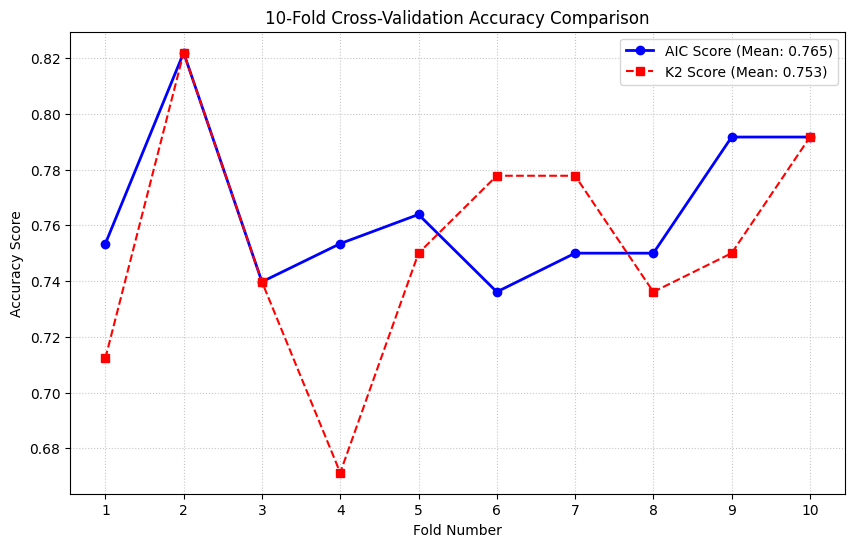

In [227]:


folds = np.arange(1, 11)

plt.figure(figsize=(10, 6))
plt.plot(folds, cv_results['AIC'], marker='o', label='AIC Score (Mean: 0.765)', color='blue', linewidth=2)
plt.plot(folds, cv_results['K2'], marker='s', label='K2 Score (Mean: 0.753)', color='red', linestyle='--')

plt.title('10-Fold Cross-Validation Accuracy Comparison')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy Score')
plt.xticks(folds)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

## Interpretation

- **HC + K2** tends to learn more expressive networks but may overfit.
- **HC + AIC** produces simpler structures with better generalization.
- Cross-validation confirms that AIC provides more stable performance.
- Probabilistic inference allows interpretable classification decisions.

Overall, Hill Climbing with AIC scoring provides the best balance between
accuracy, stability, and interpretability for diabetes outcome classification.
